# **Step 01: Data Preprocessing**
We are using the movie lens 1M dataset in this simulation. 
https://grouplens.org/datasets/movielens/1m/ 

The dataset contain 1,000,209 anonymous ratings of approximately 3,900 movies made by 6,040 MovieLens users.

Inputs: Movie Lens 1M user, movie, ratings raw data

Steps: 
1. Exploratory data analysis : Check the distribution of data mainly by gender and ratings. Summarise statistical metrics
2. Filter data: Only the users with >50 ratings and movies with >100 are filtered to remove sparse datapoints
3. Feature Engineering: Encode the genre data on movie dataset and categorical data in user dataset using multihotencoding and onehotencoding
4. Construct combine feature matrix of user and item features (gender, age, occupation, moive_genre) - Context vector
5. Saved the processed datasets


Outputs:
* user_feature_matrix.npy   (num_users  × 29)  gender(1) + age(7) + occ(21)
* movie_feature_matrix.npy  (num_movies × 18)  genre multi-hot
* X_observed.npy            (num_ratings × 47) joint context vectors
* y_observed.npy            (num_ratings,)      binary labels
* user_indices.npy          (num_ratings,)      user_idx per rating
* movie_indices.npy         (num_ratings,)      movie_idx per rating
* user_metadata.csv                             demographic labels for fairness logging
* user_id_map.csv                               original UserID → user_idx
* movie_id_map.csv                              original MovieID → movie_idx
* enc_age.pkl                                   fitted age encoder
* enc_occ.pkl                                   fitted occupation encoder


In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
#!pip uninstall numpy

In [4]:
# Install a compatible NumPy version (1.x)
#!pip install numpy==1.26.4

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import os 

First, let's download the MovieLens 1M dataset. We'll use `wget` to get the compressed file and then `tar` to extract it into a `data/ml-1m` directory.

In [6]:
import os
import urllib.request
import zipfile

# Create a directory for the data if it doesn't exist
os.makedirs('data/ml-1m', exist_ok=True)

# Download the MovieLens 1M dataset
url = 'http://files.grouplens.org/datasets/movielens/ml-1m.zip'
zip_path = 'data/ml-1m.zip'

if not os.path.exists(zip_path):
    print(f"Downloading {url}...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete!")
else:
    print(f"{zip_path} already exists, skipping download")

# Unzip the dataset
print(f"Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('data/')
print("Extraction complete!")

data/ml-1m.zip already exists, skipping download
Extracting data/ml-1m.zip...
Extraction complete!


## **User Data**

Now that the data is downloaded and extracted, update the `pd.read_csv` path to reflect its new location. The `users.dat` file is now located at `data/ml-1m/users.dat`.

In [7]:
user = pd.read_csv("data/ml-1m/users.dat", sep = "::", engine='python', header = None)
user.columns = ["user_id","gender","age","occupation","zipcode"]
user = user.drop(["zipcode"], axis = 1)
user.head()


,user_id,gender,age,occupation
0,1,F,1,10
1,2,M,56,16
2,3,M,25,15
3,4,M,45,7
4,5,M,25,20


User data distribution by gender

Male Users: 4331
Female Users: 1709
Male-to-Female Ratio: 2.53:1


C:\Users\karth\AppData\Local\Temp\ipykernel_18164\2957082496.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gender', data=user, order=['M', 'F'], palette=['#1e88e5', '#f06292'])


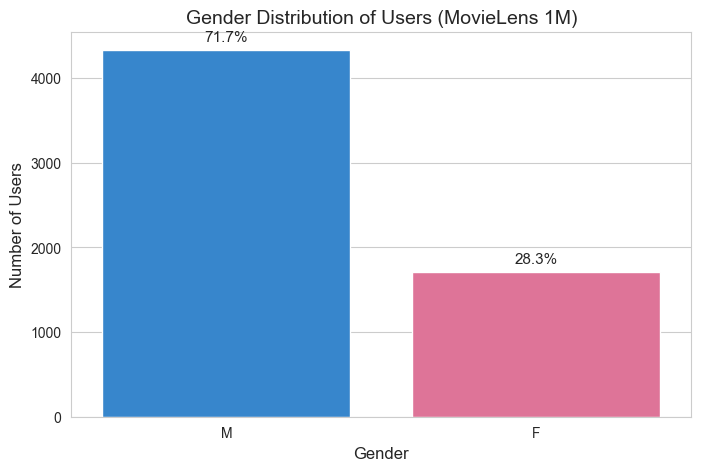

In [8]:
# 1. Get exact counts
gender_counts = user['gender'].value_counts()
male_count = gender_counts.get('M', 0)
female_count = gender_counts.get('F', 0)
total = male_count + female_count

# 2. Calculate Ratio
ratio = male_count / female_count if female_count != 0 else 0

print(f"Male Users: {male_count}")
print(f"Female Users: {female_count}")
print(f"Male-to-Female Ratio: {ratio:.2f}:1")

# 3.Plot gender distribution
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.countplot(x='gender', data=user, order=['M', 'F'], palette=['#1e88e5', '#f06292'])

plt.title('Gender Distribution of Users (MovieLens 1M)', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)

# Add percentage labels on top of bars
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), 
                textcoords = 'offset points', fontsize=11)

## **Movie Data**

Update the movie data and encode them.

* Genres: multi-hot → 18 dims
* Year:   dropped — low marginal signal on top of genres

In [9]:
movie = pd.read_csv("data/ml-1m/movies.dat", header = None, sep = "::", engine='python', encoding='latin-1')
movie.columns = ["movie_id", "movie_title", "genres"]
movie.head()

# Split genres into multiple columns
genre_features = movie['genres'].str.get_dummies('|')

# Combine movie_id with the new genre features
movie_features = pd.concat([movie['movie_id'], genre_features], axis=1)
movie_features.head()

,movie_id,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## **Ratings Data**
Now the user data and movie data are added seperatly, let's bring the ratings data which we use as the reward mechanism of contextual bandits algorithm.

The data are sorted by timestamp to simulate a natural enviorenment.

In [10]:
ratings = pd.read_csv("data/ml-1m/ratings.dat",
                   sep='::',
                   engine='python',
                   header=None,
                   names=["user_id", "movie_id", "rating", "timestamp"])
#2. CHRONOLOGICAL SORTING
ratings = ratings.sort_values(by='timestamp').reset_index(drop=True)
ratings.head()

,user_id,movie_id,rating,timestamp
0,6040,858,4,956703932
1,6040,2384,4,956703954
2,6040,593,5,956703954
3,6040,1961,4,956703977
4,6040,2019,5,956703977


rating distribution:
rating
1     5.62%
2    10.75%
3    26.11%
4    34.89%
5    22.63%
dtype: str


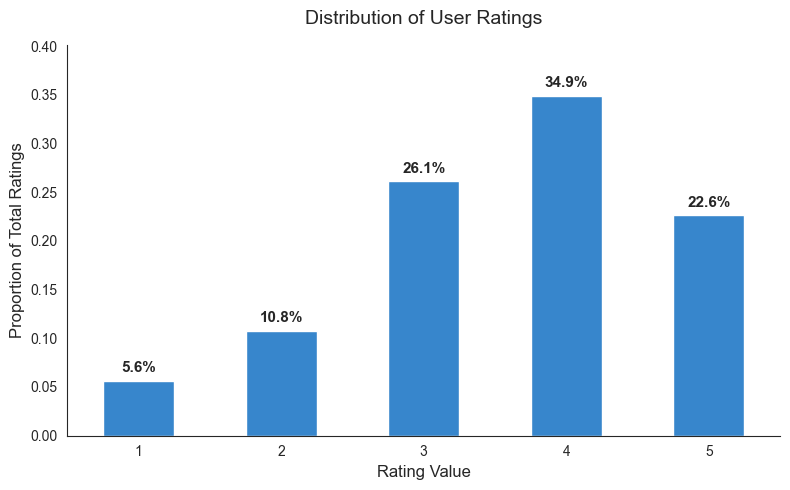

In [11]:
ratings_distribution = ratings.groupby('rating').size()

# 1. Prepare Data
dist_rating = ratings['rating'].value_counts(normalize=True).sort_index().reset_index()
dist_rating.columns = ['rating', 'percentage']

print("rating distribution:")
print((ratings_distribution/len(ratings)).apply(lambda x: f"{x:.2%}"))

# 2. Plotting
plt.figure(figsize=(8, 5))
sns.set_style("white")
ax = sns.barplot(x='rating', y='percentage', data=dist_rating, color='#1e88e5', width=0.5)

# 3. Add Percentage Labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribution of User Ratings', fontsize=14, pad=15)
plt.xlabel('Rating Value', fontsize=12)
plt.ylabel('Proportion of Total Ratings', fontsize=12)
plt.ylim(0, dist_rating['percentage'].max() * 1.15) 

sns.despine()
plt.tight_layout()
plt.show()


Statistical Summary Raw data and Filtered data

In [12]:
print(f"Number of unique users: {len(user['user_id'].unique())}")
print(f"Number of unique movies: {len(movie['movie_id'].unique())}")
print(f"Number of unique genres: {len(genre_features.columns)}")
print(f"Total number of ratings: {len(ratings)}")
print(f"Rating Density: {len(ratings) / (len(user) * len(movie)):.2%}")
print(f"distribution of ratings per user:{ratings.groupby('user_id').size().describe()}")
print(f"distribution of ratings per movie:{ratings.groupby('movie_id').size().describe()}")

movie_counts = ratings['movie_id'].value_counts()
print(f"Number of unique movies with more than 100 ratings: { len(movie_counts[movie_counts > 100])}")
user_counts = ratings['user_id'].value_counts()
print(f"Number of unique users with more than 50 ratings: { len(user_counts[user_counts > 50])}")

Number of unique users: 6040
Number of unique movies: 3883
Number of unique genres: 18
Total number of ratings: 1000209
Rating Density: 4.26%
distribution of ratings per user:count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64
distribution of ratings per movie:count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64
Number of unique movies with more than 100 ratings: 2006
Number of unique users with more than 50 ratings: 4247


All the users have rated more than 20 movies. To support NN training and to avoid bandits training on sparse data we'll take the users with more than 50 ratings.
Similarily we will consider only the movies with more than 100 ratings.

Filter the data and produce the statistical metrics of user and movie distribution and the rating density

In [13]:

# Identify movies with more than 100 ratings
movie_counts = ratings['movie_id'].value_counts()
movies_to_keep = movie_counts[movie_counts >= 100].index

# Identify users with more than 50 ratings
user_counts = ratings['user_id'].value_counts()
users_to_keep = user_counts[user_counts >= 50].index

ratings_filtered = ratings[
    ratings['user_id'].isin(users_to_keep) &
    ratings['movie_id'].isin(movies_to_keep)
].copy()

print(f"Original number of ratings: {len(ratings)}")
print(f"Number of ratings after filtering: {len(ratings_filtered)}")
display(ratings_filtered.head())

movies_filtered = movie_features[movie_features['movie_id'].isin(movies_to_keep)].copy().reset_index(drop=True)
print(f"Original number of movies: {len(movie_features)}")
print(f"Number of movies after filtering: {len(movies_filtered)}")

user_filtered = user[user['user_id'].isin(users_to_keep)].copy().reset_index(drop=True)
print(f"Original number of users: {len(user)}")
print(f"Number of users after filtering: {len(user_filtered)}")
print(f"Density of ratings after filtering: {len(ratings_filtered) / (len(user_filtered) * len(movies_filtered)):.2%}")

print(f"distribution of ratings per user:{ratings_filtered.groupby('user_id').size().describe()}")
print(f"distribution of ratings per movie:{ratings_filtered.groupby('movie_id').size().describe()}")


Original number of ratings: 1000209
Number of ratings after filtering: 887961


,user_id,movie_id,rating,timestamp
0,6040,858,4,956703932
1,6040,2384,4,956703954
2,6040,593,5,956703954
3,6040,1961,4,956703977
4,6040,2019,5,956703977


Original number of movies: 3883
Number of movies after filtering: 2019
Original number of users: 6040
Number of users after filtering: 4297
Density of ratings after filtering: 10.24%
distribution of ratings per user:count    4297.000000
mean      206.646730
std       184.692701
min        24.000000
25%        83.000000
50%       140.000000
75%       265.000000
max      1568.000000
dtype: float64
distribution of ratings per movie:count    2019.000000
mean      439.802377
std       390.502238
min        89.000000
25%       175.000000
50%       300.000000
75%       561.000000
max      2758.000000
dtype: float64


Male Users: 3144
Female Users: 1153
Male-to-Female Ratio: 2.73:1


C:\Users\karth\AppData\Local\Temp\ipykernel_18164\2975374703.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gender', data=user_filtered, order=['M', 'F'], palette=['#1e88e5', '#f06292'])


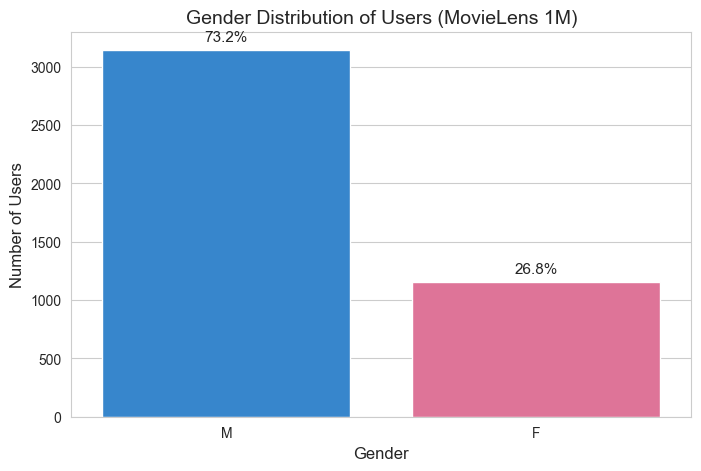

In [14]:
# 1. Get exact counts
gender_counts = user_filtered['gender'].value_counts()
male_count = gender_counts.get('M', 0)
female_count = gender_counts.get('F', 0)
total = male_count + female_count

# 2. Calculate Ratio
ratio = male_count / female_count if female_count != 0 else 0

print(f"Male Users: {male_count}")
print(f"Female Users: {female_count}")
print(f"Male-to-Female Ratio: {ratio:.2f}:1")

# 3. Plot gender distribution after filtering
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.countplot(x='gender', data=user_filtered, order=['M', 'F'], palette=['#1e88e5', '#f06292'])

plt.title('Gender Distribution of Users (MovieLens 1M)', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)

# Add percentage labels on top of bars
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), 
                textcoords = 'offset points', fontsize=11)

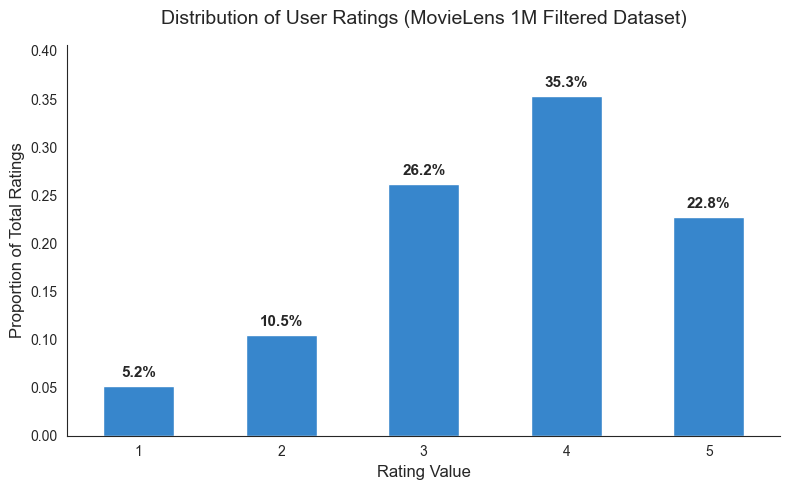

In [15]:
# 1. Prepare Data
dist_df = ratings_filtered['rating'].value_counts(normalize=True).sort_index().reset_index()
dist_df.columns = ['rating', 'percentage']

# 2. Plotting
plt.figure(figsize=(8, 5))
sns.set_style("white")
ax = sns.barplot(x='rating', y='percentage', data=dist_df, color='#1e88e5', width=0.5)

# 3. Add Percentage Labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribution of User Ratings (MovieLens 1M Filtered Dataset)', fontsize=14, pad=15)
plt.xlabel('Rating Value', fontsize=12)
plt.ylabel('Proportion of Total Ratings', fontsize=12)
plt.ylim(0, dist_df['percentage'].max() * 1.15) 

sns.despine()
plt.tight_layout()
plt.show()

Build reindex mapping

Because the original MovieLens IDs have gaps after filtering. Map them to clean consecutive integers so they work directly as matrix row/column indices.

In [16]:
# sorted for reproducibility
unique_users  = sorted(users_to_keep.tolist())
unique_movies = sorted(movies_to_keep.tolist())

# original ID → consecutive integer index
user_id_to_idx  = {uid: idx for idx, uid in enumerate(unique_users)}
movie_id_to_idx = {mid: idx for idx, mid in enumerate(unique_movies)}

# reverse: consecutive integer → original ID (useful for logging and debugging)
idx_to_user_id  = {idx: uid for uid, idx in user_id_to_idx.items()}
idx_to_movie_id = {idx: mid for mid, idx in movie_id_to_idx.items()}

num_users  = len(unique_users)
num_movies = len(unique_movies)

print(f"  num_users  = {num_users}")
print(f"  num_movies = {num_movies}")

# add reindexed columns to the ratings dataframe for convenience
ratings_filtered['user_idx']  = ratings_filtered['user_id'].map(user_id_to_idx)
ratings_filtered['movie_idx'] = ratings_filtered['movie_id'].map(movie_id_to_idx)
user_filtered['user_idx']    = user_filtered['user_id'].map(user_id_to_idx)
movies_filtered['movie_idx']  = movies_filtered['movie_id'].map(movie_id_to_idx)




  num_users  = 4297
  num_movies = 2019


Encode the user features using OneHotEncoding

In [17]:
from sklearn.preprocessing import OneHotEncoder

user_filtered = user_filtered.sort_values(by='user_idx').reset_index(drop=True)

columnsToEncode = ["age","gender","occupation"]
# Changed 'sparse=False' to 'sparse_output=False' to fix the TypeError
myEncoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
myEncoder.fit(user_filtered[columnsToEncode])

user_features = pd.concat([user_filtered.drop(columns=columnsToEncode),
                           pd.DataFrame(myEncoder.transform(user_filtered[columnsToEncode]),
                                        columns = myEncoder.get_feature_names_out(columnsToEncode))], axis=1).reindex()
user_features.head()


,user_id,user_idx,age_1,age_18,age_25,age_35,age_45,age_50,age_56,gender_F,...,occupation_11,occupation_12,occupation_13,occupation_14,occupation_15,occupation_16,occupation_17,occupation_18,occupation_19,occupation_20
0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,5,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Stack into final matrix

The one-hot encoded features are already in the user_features DataFrame. Extract these columns to form the user_feature_matrix and drop 'user_id' and 'user_idx' as they are identifiers, not features.

The shape is (num_users, 7 age categories + 2 gender categories + 21 occupation categories) = (num_users, 30)


Then create movie_feature_matrix similar to user_feature_matrix that should be ordered by movie_idx to allow direct integer indexing.


In [18]:
user_feature_matrix = user_features.drop(columns=["user_id", "user_idx"]).values
print(f"  user_feature_matrix shape: {user_feature_matrix.shape}")

movie_feature_matrix = movies_filtered.sort_values(by='movie_idx').drop(columns=["movie_id", "movie_idx"]).values
print(f"  movie_feature_matrix shape: {movie_feature_matrix.shape}")

  user_feature_matrix shape: (4297, 30)
  movie_feature_matrix shape: (2019, 18)


JOINT CONTEXT VECTORS AND BINARY LABELS

x(u, m) = concat(user_vector(u), movie_vector(m)) = 48-dim
y(u, m) = 1 if rating >= RATING_THRESHOLD else 0

In [19]:
num_ratings   = len(ratings_filtered)
X             = np.zeros((num_ratings, 48), dtype=np.float32)
y_observed     = np.zeros(num_ratings,       dtype=np.float32)  # Use observed ratings for labels
user_indices  = np.zeros(num_ratings,       dtype=np.int32)
movie_indices = np.zeros(num_ratings,       dtype=np.int32)

# Use enumerate to get a proper sequential index 'j' for the output arrays
for j, (i, row) in enumerate(ratings_filtered.iterrows()): # 'i' is the original index, 'j' is the sequential index
    u = int(row['user_idx'])
    m = int(row['movie_idx'])
    X[j] = np.concatenate([user_feature_matrix[u], movie_feature_matrix[m]])
    user_indices[j]  = u
    movie_indices[j] = m
    y_observed[j] = 1.0 if row['rating'] >= 4.0 else 0.0  # Binarize ratings: 1 for 4 or 5, else 0
print(f"  X shape       : {X.shape}")
print(f"  y_observed shape : {y_observed.shape}")


  X shape       : (887961, 48)
  y_observed shape : (887961,)


USER METADATA TABLE

In [20]:
age_bracket_labels = {
    1: 'Under 18', 18: '18-24',  25: '25-34',
    35: '35-44',   45: '45-49',  50: '50-55', 56: '56+'
}

occupation_labels = {
    0:  'other',                1:  'academic/educator',
    2:  'artist',               3:  'clerical/admin',
    4:  'college/grad student', 5:  'customer service',
    6:  'doctor/health care',   7:  'executive/managerial',
    8:  'farmer',               9:  'homemaker',
    10: 'K-12 student',         11: 'lawyer',
    12: 'programmer',           13: 'retired',
    14: 'sales/marketing',      15: 'scientist',
    16: 'self-employed',        17: 'technician/engineer',
    18: 'tradesman/craftsman',  19: 'unemployed',
    20: 'writer'
}

user_metadata_df = user_filtered[
    ['user_id', 'gender', 'age', 'occupation', 'user_idx']
].copy().sort_values('user_idx').reset_index(drop=True)

user_metadata_df['age_group'] = user_metadata_df['age'].map(age_bracket_labels)
user_metadata_df['occ_label'] = user_metadata_df['occupation'].map(occupation_labels)

print(f"  Shape: {user_metadata_df.shape}")
print(f"\n  Gender distribution:")
print(user_metadata_df['gender'].value_counts().to_string(header=False))
print(f"\n  Age distribution:")
print(user_metadata_df['age_group'].value_counts().to_string(header=False))
print(f"\n  Top 5 occupations:")
print(user_metadata_df['occ_label'].value_counts().head(5).to_string(header=False))

  Shape: (4297, 7)

  Gender distribution:
M    3144
F    1153

  Age distribution:
25-34       1564
35-44        853
18-24        787
45-49        376
50-55        340
56+          221
Under 18     156

  Top 5 occupations:
college/grad student    550
other                   507
executive/managerial    456
academic/educator       367
technician/engineer     351


In [21]:
errors = []

if np.isnan(user_feature_matrix).any(): errors.append("NaN in user_feature_matrix")
if np.isnan(movie_feature_matrix).any():errors.append("NaN in movie_feature_matrix")


if user_feature_matrix.shape != (num_users, 30):
    errors.append(f"user_feature_matrix shape wrong: {user_feature_matrix.shape}")
if movie_feature_matrix.shape != (num_movies, 18):
    errors.append(f"movie_feature_matrix shape wrong: {movie_feature_matrix.shape}")


# Gender columns are now at indices 7 and 8 (after 7 age columns)
if not np.all(np.isin(user_feature_matrix[:, 7:9], [0.0, 1.0])):
    errors.append("Gender columns must be binary (0 or 1)")

# Age one-hot features are at indices 0 to 6 (7 columns)
if not np.all(user_feature_matrix[:, 0:7].sum(axis=1) == 1.0):
    errors.append("Age one-hot must sum to 1 for every user")

# Occupation one-hot features are at indices 9 to 29 (21 columns)
if not np.all(user_feature_matrix[:, 9:30].sum(axis=1) == 1.0):
    errors.append("Occupation one-hot must sum to 1 for every user")

if not set(np.unique(movie_feature_matrix)).issubset({0.0, 1.0}):
    errors.append("Genre features must be binary")


if errors:
    for e in errors:
        print(f"  FAIL : {e}")
    raise ValueError("Validation failed")
else:
    print("  All checks passed.")

  All checks passed.


Save to disk

In [22]:
OUTPUT_DIR = 'processed_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(os.path.join(OUTPUT_DIR, 'user_feature_matrix.npy'), user_feature_matrix)
np.save(os.path.join(OUTPUT_DIR, 'movie_feature_matrix.npy'), movie_feature_matrix)
np.save(os.path.join(OUTPUT_DIR, 'X_observed.npy'), X)
np.save(os.path.join(OUTPUT_DIR, 'y_observed.npy'), y_observed)
np.save(os.path.join(OUTPUT_DIR, 'user_indices.npy'), user_indices)
np.save(os.path.join(OUTPUT_DIR, 'movie_indices.npy'),        movie_indices)
np.save(os.path.join(OUTPUT_DIR, 'ratings_filtered.npy'), ratings_filtered)
ratings_filtered.to_csv(os.path.join(OUTPUT_DIR, 'ratings_filtered.csv'), index=False)

user_metadata_df.to_csv(
    os.path.join(OUTPUT_DIR, 'user_metadata.csv'), index=False)

pd.DataFrame(list(user_id_to_idx.items()),
             columns=['original_user_id', 'user_idx']).to_csv(os.path.join(OUTPUT_DIR, 'user_id_map.csv'), index=False)

pd.DataFrame(list(movie_id_to_idx.items()),
             columns=['original_movie_id', 'movie_idx']).to_csv(os.path.join(OUTPUT_DIR, 'movie_id_map.csv'), index=False)


with open(os.path.join(OUTPUT_DIR, 'user_features_encoder.pkl'), 'wb') as f:
    pickle.dump(myEncoder, f)

print(f"\n  Saved to '{OUTPUT_DIR}/'")
print(f"    user_feature_matrix.npy   {user_feature_matrix.shape}")
print(f"    movie_feature_matrix.npy  {movie_feature_matrix.shape}")
print(f"    X_observed.npy           {X.shape}")
print(f"    y_observed.npy           {y_observed.shape}")
print(f"    user_indices.npy          {user_indices.shape}")
print(f"    movie_indices.npy         {movie_indices.shape}")
print(f"    user_metadata.csv         {user_metadata_df.shape}")
print(f"    user_features_encoder.pkl OneHotEncoder (user features)")
print(f"    ratings_filtered.npy      {ratings_filtered.shape}")
print("\nDone.")




  Saved to 'processed_data/'
    user_feature_matrix.npy   (4297, 30)
    movie_feature_matrix.npy  (2019, 18)
    X_observed.npy           (887961, 48)
    y_observed.npy           (887961,)
    user_indices.npy          (887961,)
    movie_indices.npy         (887961,)
    user_metadata.csv         (4297, 7)
    user_features_encoder.pkl OneHotEncoder (user features)
    ratings_filtered.npy      (887961, 6)

Done.


# **Reward Oracle — Matrix Factorization (SVD)**

Loads the filtered rating data produced by feature_engineering,
trains SVD via the Surprise library, reconstructs the full user-movie
rating matrix, binarizes it, and saves the dense oracle matrix.

Input: Filtered rating matrix

Pipeline:
1. Load processed data
2. Build Surprise dataset from filtered ratings. Use the actual 1–5 star ratings for MF training instead of proxy values. This gives SVD a richer signal.
3. Train/val split → train SVD → validate on held-out ratings
4. Reconstruct full dense predicted rating matrix
5. Binarize at threshold → oracle matrix
6. Validate oracle
7. Save outputs

Outputs:
* oracle.npy         - (num_users × num_movies) - binary reward matrix
* oracle_raw.npy -      (num_users × num_movies) -  predicted raw ratings (float)
* svd_model.pkl -       fitted Surprise SVD model
* oracle_report.txt -  validation metrics


In [23]:

#!pip install surprise

In [24]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split
from sklearn.metrics import roc_auc_score, classification_report

Load processed data

In [25]:
PROCESSED_DIR      = './processed_data'  
OUTPUT_DIR         = './processed_data'   # save oracle here 
RATING_THRESHOLD   = 4              # predicted rating >= this → oracle = 1
SVD_N_FACTORS      = 50              # latent factors
SVD_N_EPOCHS       = 20              # SGD epochs inside Surprise SVD
SVD_LR             = 0.005           # learning rate for SGD
SVD_REG            = 0.02            # L2 regularisation
VAL_FRACTION       = 0.10            # fraction of observed ratings held out
RANDOM_SEED        = 42

AUC_TARGET         = 0.72            # minimum acceptable AUC on val set
RMSE_TARGET        = 0.90            # maximum acceptable RMSE on val set

os.makedirs(OUTPUT_DIR, exist_ok=True)

raw = pd.read_csv('./data/ml-1m/ratings.dat', sep='::', engine='python',
                   names=["user_id", "movie_id", "rating", "timestamp"])

raw = raw[raw['user_id'].isin(user_id_to_idx.keys()) &
          raw['movie_id'].isin(movie_id_to_idx.keys())].copy()
raw['user_idx']  = raw['user_id'].map(user_id_to_idx)
raw['movie_idx'] = raw['movie_id'].map(movie_id_to_idx)
ratings_df = raw[['user_idx', 'movie_idx', 'rating']]

print(f"  Ratings loaded : {len(ratings_df):,}")
print(f"  Rating range   : {ratings_df['rating'].min():.1f} – "
      f"{ratings_df['rating'].max():.1f}")

  Ratings loaded : 887,961
  Rating range   : 1.0 – 5.0


Build Surprise Dataset

In [26]:
 # Surprise requires a Reader that knows the rating scale.

rating_min = ratings_df['rating'].min()
rating_max = ratings_df['rating'].max()

reader  = Reader(rating_scale=(rating_min, rating_max))
dataset = Dataset.load_from_df(
    ratings_df[['user_idx', 'movie_idx', 'rating']],
    reader
)

print(f"  Rating scale for Surprise: ({rating_min}, {rating_max})")


  Rating scale for Surprise: (1, 5)


Train SVD

In [28]:
print(f"  n_factors = {SVD_N_FACTORS}")
print(f"  n_epochs  = {SVD_N_EPOCHS}")
print(f"  lr_all    = {SVD_LR}")
print(f"  reg_all   = {SVD_REG}")

# split into train (90%) and validation (10%)
trainset, valset = surprise_split(
    dataset,
    test_size=VAL_FRACTION,
    random_state=RANDOM_SEED
)

print(f"\n  Train interactions : {trainset.n_ratings:,}")
print(f"  Val   interactions : {len(valset):,}")

svd = SVD(
    n_factors  = SVD_N_FACTORS,
    n_epochs   = SVD_N_EPOCHS,
    lr_all     = SVD_LR,
    reg_all    = SVD_REG,
    random_state = RANDOM_SEED,
    verbose    = True
)

svd.fit(trainset)
print("\n  Training complete.")


  n_factors = 50
  n_epochs  = 20
  lr_all    = 0.005
  reg_all   = 0.02

  Train interactions : 799,164
  Val   interactions : 88,797
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

  Training complete.


Validate on held out ratings

In [29]:

# raw predictions on the val set
predictions = svd.test(valset)

# RMSE on raw predicted ratings
rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions,  verbose=False)
print(f"  RMSE : {rmse:.4f}  (target < {RMSE_TARGET})")
print(f"  MAE  : {mae:.4f}")

# AUC on binarized predictions vs binarized true labels
val_true_raw  = np.array([pred.r_ui for pred in predictions])
val_pred_raw  = np.array([pred.est  for pred in predictions])

val_true_bin  = (val_true_raw  >= RATING_THRESHOLD).astype(int)
val_pred_bin  = (val_pred_raw  >= RATING_THRESHOLD).astype(int)

# AUC uses predicted score (continuous), not binarized prediction
auc = roc_auc_score(val_true_bin, val_pred_raw)
print(f"  AUC  : {auc:.4f}  (target > {AUC_TARGET})")

print("\n  Classification report (at threshold):")
print(classification_report(val_true_bin, val_pred_bin,
                             target_names=['disliked (0)', 'liked (1)']))

# warn if targets not met
if rmse > RMSE_TARGET:
    print(f"  WARNING: RMSE {rmse:.4f} exceeds target {RMSE_TARGET}. "
          f"Consider increasing SVD_N_FACTORS.")
if auc < AUC_TARGET:
    print(f"  WARNING: AUC {auc:.4f} below target {AUC_TARGET}. "
          f"Consider increasing SVD_N_FACTORS or SVD_N_EPOCHS.")


  RMSE : 0.8498  (target < 0.9)
  MAE  : 0.6668
  AUC  : 0.8172  (target > 0.72)

  Classification report (at threshold):
              precision    recall  f1-score   support

disliked (0)       0.55      0.91      0.68     36838
   liked (1)       0.88      0.46      0.61     51959

    accuracy                           0.65     88797
   macro avg       0.71      0.69      0.65     88797
weighted avg       0.74      0.65      0.64     88797



Retain on full dataset

After validating hyperparameters, retrain on ALL observed ratings so the full matrix reconstruction uses maximum available information.

In [31]:
full_trainset = dataset.build_full_trainset()
svd.fit(full_trainset)
print("  Retrained on full dataset.")

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
  Retrained on full dataset.


Reconstruct full rating matrix

Predict rating for every (user, movie) pair — observed or not. This fills the sparse rating matrix into a dense one.

In [33]:
print(f"  Predicting {num_users * num_movies:,} pairs "
      f"({num_users} users × {num_movies} movies)")

# build all (user_idx, movie_idx) pairs
all_users  = np.repeat(np.arange(num_users),  num_movies)  
all_movies = np.tile(np.arange(num_movies),   num_users)   

# predict in one vectorised call using svd internals
# svd.predict() is per-pair but slow in a loop — use matrix multiplication directly
# SVD decomposes R ≈ μ + bu + bi + pu · qi
# where:
#   μ  = global mean
#   bu = user bias vector  (num_users,)
#   bi = item bias vector  (num_movies,)
#   pu = user latent matrix (num_users  × n_factors)
#   qi = item latent matrix (num_movies × n_factors)

# extract learned parameters from trained model
global_mean = svd.trainset.global_mean

# Surprise stores biases and factors in inner id space.
# Need to map our integer indices back to Surprise's inner ids.
# robust mapping — iterate Surprise's internal dict directly
inner_uid_map = {}
for raw_id, inner_id in svd.trainset._raw2inner_id_users.items():
    try:
        our_idx = int(raw_id)
        if 0 <= our_idx < num_users:
            inner_uid_map[inner_id] = our_idx
    except (ValueError, TypeError):
        continue

inner_iid_map = {}
for raw_id, inner_id in svd.trainset._raw2inner_id_items.items():
    try:
        our_idx = int(raw_id)
        if 0 <= our_idx < num_movies:
            inner_iid_map[inner_id] = our_idx
    except (ValueError, TypeError):
        continue

print(f"Users mapped : {len(inner_uid_map)} / {num_users}")
print(f"Movies mapped: {len(inner_iid_map)} / {num_movies}")

# build user and item parameter arrays aligned to 0..N-1 indices
bu = np.zeros(num_users,            dtype=np.float32)
bi = np.zeros(num_movies,           dtype=np.float32)
pu = np.zeros((num_users,  SVD_N_FACTORS), dtype=np.float32)
qi = np.zeros((num_movies, SVD_N_FACTORS), dtype=np.float32)

for inner_id, our_idx in inner_uid_map.items():
    bu[our_idx] = svd.bu[inner_id]
    pu[our_idx] = svd.pu[inner_id]

for inner_id, our_idx in inner_iid_map.items():
    bi[our_idx] = svd.bi[inner_id]
    qi[our_idx] = svd.qi[inner_id]

# Vectorised full matrix reconstruction:
# R_hat[u, m] = μ + bu[u] + bi[m] + pu[u] · qi[m]
R_raw = (
    global_mean
    + bu[:, np.newaxis]          # (num_users, 1)   broadcasts over movies
    + bi[np.newaxis, :]          # (1, num_movies)  broadcasts over users
    + pu @ qi.T                  # (num_users, num_movies)  dot product
)
# R_raw shape: (num_users, num_movies)

print(f"  R_raw shape    : {R_raw.shape}")
print(f"  R_raw range    : [{R_raw.min():.3f}, {R_raw.max():.3f}]")
print(f"  R_raw mean     : {R_raw.mean():.3f}")



  Predicting 8,675,643 pairs (4297 users × 2019 movies)
Users mapped : 4297 / 4297
Movies mapped: 2019 / 2019
  R_raw shape    : (4297, 2019)
  R_raw range    : [-0.763, 6.374]
  R_raw mean     : 3.393


In [34]:
print(f"global_mean : {global_mean:.4f}")
print(f"bu range    : [{bu.min():.4f}, {bu.max():.4f}]")
print(f"bi range    : [{bi.min():.4f}, {bi.max():.4f}]")
print(f"pu range    : [{pu.min():.4f}, {pu.max():.4f}]")
print(f"qi range    : [{qi.min():.4f}, {qi.max():.4f}]")
print(f"R_raw range : [{R_raw.min():.4f}, {R_raw.max():.4f}]")
print(f"R_raw mean  : {R_raw.mean():.4f}")
print(f"R_raw std   : {R_raw.std():.4f}")

# how many predictions fall above various thresholds
for t in [3.0, 3.5, 4.0, 4.5, 5.0]:
    frac = (R_raw >= t).mean()
    print(f"  Fraction >= {t} : {frac:.4f}")

global_mean : 3.5998
bu range    : [-2.3583, 1.4709]
bi range    : [-1.9899, 1.0054]
pu range    : [-1.2795, 1.5389]
qi range    : [-1.0912, 1.0680]
R_raw range : [-0.7626, 6.3743]
R_raw mean  : 3.3927
R_raw std   : 0.7085
  Fraction >= 3.0 : 0.7253
  Fraction >= 3.5 : 0.4750
  Fraction >= 4.0 : 0.2023
  Fraction >= 4.5 : 0.0406
  Fraction >= 5.0 : 0.0026


Positive rate of 0.20 is realistic. In a real recommendation system, a 20% success rate on random recommendations is reasonable. It is hard enough that the bandit needs to learn — a random policy succeeds 20% of the time, so a good bandit should push well above that. It is not so sparse that the bandit sees almost no positive feedback.
The learning signal is meaningful. With 20% positives, the bandit gets roughly 2,000 positive rewards in 10,000 timesteps under a random policy. A well-trained NeuralLinUCB should push that to 3,000–4,000, giving you a clear and measurable improvement to report.

Binarize → Oracle Matrix

In [35]:
oracle = (R_raw >= RATING_THRESHOLD).astype(np.float32)
# oracle[u, m] = 1.0  if predicted rating >= 4  (bandit reward = 1)
# oracle[u, m] = 0.0  otherwise                 (bandit reward = 0)

positive_rate = oracle.mean()
print(f"  oracle shape         : {oracle.shape}")
print(f"  oracle positive rate : {positive_rate:.3f}  "
      f"(fraction of (user,movie) pairs predicted as liked)")

if positive_rate > 0.80:
    print("  WARNING: Very high positive rate — consider raising RATING_THRESHOLD")
if positive_rate < 0.20:
    print("  WARNING: Very low positive rate — consider lowering RATING_THRESHOLD")


  oracle shape         : (4297, 2019)
  oracle positive rate : 0.202  (fraction of (user,movie) pairs predicted as liked)


Qualitative Sanity Check

In [38]:
# Load the movie_id_map from the CSV file
movie_id_map = pd.read_csv(os.path.join(PROCESSED_DIR, 'movie_id_map.csv'))

# For 5 random users, show their top-5 oracle-recommended movies
np.random.seed(RANDOM_SEED)
sample_users = np.random.choice(num_users, size=5, replace=False)

# load movie id map for readable output
idx_to_movie_id = dict(zip(movie_id_map['movie_idx'], movie_id_map['original_movie_id']))

# load original movies.dat for titles — best effort, skip if not available
try:
    movies_raw = pd.read_csv(
        './data/ml-1m/movies.dat', sep='::', engine='python',
        names=['MovieID', 'Title', 'Genres'], encoding='latin-1'
    )
    movieid_to_title = dict(zip(movies_raw['MovieID'], movies_raw['Title']))
except FileNotFoundError:
    movieid_to_title = {}

print("  Top-5 oracle recommendations for 5 sample users:")
for u in sample_users:
    top5_movie_idxs = np.argsort(R_raw[u])[::-1][:5]
    titles = []
    for m in top5_movie_idxs:
        orig_mid = idx_to_movie_id.get(m, m)
        title    = movieid_to_title.get(orig_mid, f"MovieID {orig_mid}")
        titles.append(title)
    print(f"\n    User {u} (idx):")
    for t in titles:
        print(f"      {t}")

  Top-5 oracle recommendations for 5 sample users:

    User 1860 (idx):
      Star Wars: Episode IV - A New Hope (1977)
      Raiders of the Lost Ark (1981)
      Shawshank Redemption, The (1994)
      Rear Window (1954)
      Schindler's List (1993)

    User 2743 (idx):
      Casablanca (1942)
      Shawshank Redemption, The (1994)
      It's a Wonderful Life (1946)
      Raiders of the Lost Ark (1981)
      To Kill a Mockingbird (1962)

    User 1964 (idx):
      Blade Runner (1982)
      Close Shave, A (1995)
      Godfather, The (1972)
      Usual Suspects, The (1995)
      Apocalypse Now (1979)

    User 2323 (idx):
      Shawshank Redemption, The (1994)
      Close Shave, A (1995)
      Some Like It Hot (1959)
      Godfather, The (1972)
      Usual Suspects, The (1995)

    User 3619 (idx):
      Godfather, The (1972)
      Schindler's List (1993)
      One Flew Over the Cuckoo's Nest (1975)
      Shawshank Redemption, The (1994)
      Usual Suspects, The (1995)


Validate Oracle against observed ratings

In [39]:

user_indices  = np.load(os.path.join(PROCESSED_DIR, 'user_indices.npy'))
movie_indices = np.load(os.path.join(PROCESSED_DIR, 'movie_indices.npy'))
y_observed   = np.load(os.path.join(PROCESSED_DIR, 'y_observed.npy'))

# compare oracle predictions to actual binarized observed ratings
oracle_on_observed = oracle[user_indices, movie_indices]
auc_oracle = roc_auc_score(y_observed, oracle_on_observed)
agreement  = (oracle_on_observed == y_observed).mean()

print(f"  Oracle AUC vs observed labels    : {auc_oracle:.4f}  "
      f"(target > {AUC_TARGET})")
print(f"  Oracle agreement with observed   : {agreement:.3f}")

# check oracle per demographic group — early fairness signal
user_metadata = pd.read_csv(os.path.join(PROCESSED_DIR, 'user_metadata.csv'))
uid_to_gender = dict(zip(user_metadata['user_idx'], user_metadata['gender']))

female_mask = np.array([uid_to_gender.get(u, 'M') == 'F' for u in user_indices])
male_mask   = ~female_mask

if female_mask.sum() > 0 and male_mask.sum() > 0:
    auc_f = roc_auc_score(y_observed[female_mask], oracle_on_observed[female_mask])
    auc_m = roc_auc_score(y_observed[male_mask],   oracle_on_observed[male_mask])
    print(f"\n  Oracle AUC by gender:")
    print(f"    Female : {auc_f:.4f}")
    print(f"    Male   : {auc_m:.4f}")
    print(f"    Gap    : {abs(auc_f - auc_m):.4f}")

if auc_oracle < AUC_TARGET:
    print(f"\n  WARNING: Oracle AUC {auc_oracle:.4f} below target {AUC_TARGET}.")
    print("  Consider increasing SVD_N_FACTORS (try 100 or 200).")
else:
    print(f"\n  Oracle meets AUC target.")


  Oracle AUC vs observed labels    : 0.7290  (target > 0.72)
  Oracle agreement with observed   : 0.694

  Oracle AUC by gender:
    Female : 0.7223
    Male   : 0.7311
    Gap    : 0.0088

  Oracle meets AUC target.


Save binary output separately which will be used to train the Neural Network

In [41]:
y_oracle = np.zeros(num_ratings,       dtype=np.float32)

# Use enumerate to get a proper sequential index 'j' for the output arrays
for j, (i, row) in enumerate(ratings_filtered.iterrows()): # 'i' is the original index, 'j' is the sequential index
    u = int(row['user_idx'])
    m = int(row['movie_idx'])
    y_oracle[j] = oracle[u, m]  # Use oracle label instead of binarized rating

print(f"  y_oracle shape       : {y_oracle.shape}")
print(f"  Positive rate : {y_oracle.mean():.3f}  "
      f"({int(y_oracle.sum())} positives / {len(y_oracle)} total)")

  y_oracle shape       : (887961,)
  Positive rate : 0.320  (283847 positives / 887961 total)


Save Outputs

In [42]:
# binary oracle — what the simulation loop queries
np.save(os.path.join(OUTPUT_DIR, 'oracle.npy'), oracle)

# raw predicted ratings — useful for debugging and threshold sensitivity
np.save(os.path.join(OUTPUT_DIR, 'oracle_raw.npy'), R_raw.astype(np.float32))

# fitted SVD model
with open(os.path.join(OUTPUT_DIR, 'svd_model.pkl'), 'wb') as f:
    pickle.dump(svd, f)

#y_oracle — binarized oracle labels for the observed ratings 
np.save(os.path.join(OUTPUT_DIR, 'y_oracle.npy'), y_oracle)

# validation report
report_lines = [
    "Reward Oracle Validation Report",
    "=" * 40,
    f"SVD n_factors    : {SVD_N_FACTORS}",
    f"SVD n_epochs     : {SVD_N_EPOCHS}",
    f"SVD lr           : {SVD_LR}",
    f"SVD reg          : {SVD_REG}",
    f"Rating threshold : {RATING_THRESHOLD}",
    "",
    f"RMSE (val set)   : {rmse:.4f}  (target < {RMSE_TARGET})",
    f"MAE  (val set)   : {mae:.4f}",
    f"AUC  (val set)   : {auc:.4f}  (target > {AUC_TARGET})",
    "",
    f"Oracle shape     : {oracle.shape}",
    f"Positive rate    : {positive_rate:.3f}",
    f"Oracle AUC vs observed : {auc_oracle:.4f}",
    f"Oracle agreement : {agreement:.3f}",
]
with open(os.path.join(OUTPUT_DIR, 'oracle_report.txt'), 'w') as f:
    f.write('\n'.join(report_lines))

print(f"  oracle.npy          {oracle.shape}  binary reward matrix")
print(f"  oracle_raw.npy      {R_raw.shape}  predicted raw ratings")
print(f"  svd_model.pkl       fitted SVD model")
print(f"  oracle_report.txt   validation metrics")
print("\nReward oracle complete.")


  oracle.npy          (4297, 2019)  binary reward matrix
  oracle_raw.npy      (4297, 2019)  predicted raw ratings
  svd_model.pkl       fitted SVD model
  oracle_report.txt   validation metrics

Reward oracle complete.


In [48]:
errors = []
if np.isnan(y_oracle).any():                   errors.append("NaN in y_oracle")

if not set(np.unique(y_oracle)).issubset({0.0, 1.0}):
    errors.append("Labels must be 0 or 1 only")

if errors:
    for e in errors:
        print(f"  FAIL : {e}")
    raise ValueError("Validation failed")
else:
    print("  All checks passed.")

  All checks passed.


# **Contextual Neural Bandit**

**Neural Network Training — NeuralLinUCB Feature Extractor**

* Trains a binary classifier on observed (user, movie, label) pairs.
* After training, the output layer is removed and the frozen hidden layers serve as the feature extractor φ(x): R^48 → R^64 for LinUCB.

Architecture:

    Input(47) → Linear(128) + BN + ReLU + Dropout
              → Linear(64)  + BN + ReLU + Dropout   ← representation z
              → Linear(1)                           ← removed after training

Outputs:

* feature_extractor.pt    frozen network weights (hidden layers only)
* results/combined_log_NeuralLinUCB.csv
* results/all_models_summary.csv

In [50]:
import numpy as np
import pandas as pd
import os
import json

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report


PROCESSED_DIR   = './processed_data' 
OUTPUT_DIR      = './processed_data'
RANDOM_SEED     = 42

# architecture
INPUT_DIM  = 48    # 18 genre pref + 30 user features
HIDDEN_1   = 128   # wider — richer features justify more capacity
HIDDEN_2   = 64   # representation dim for LinUCB
DROPOUT    = 0.1

# training
LEARNING_RATE   = 5e-4
BATCH_SIZE      = 256
MAX_EPOCHS      = 50
PATIENCE        = 5       # early stopping patience on val AUC
VAL_FRACTION    = 0.10
TEST_FRACTION   = 0.10

# targets
AUC_TARGET      = 0.72
ACC_TARGET      = 0.65

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


Load Data

In [51]:
X = np.load(os.path.join(PROCESSED_DIR, 'X_observed.npy'))   # (N, 36)
y = np.load(os.path.join(PROCESSED_DIR, 'y_oracle.npy'))   # (N,)

print(f"  X shape        : {X.shape}")
print(f"  y shape        : {y.shape}")
print(f"  Positive rate  : {y.mean():.3f}")
print(f"  Input dim      : {X.shape[1]}")

assert X.shape[1] == INPUT_DIM, \
    f"Expected input dim {INPUT_DIM}, got {X.shape[1]}"


  X shape        : (887961, 48)
  y shape        : (887961,)
  Positive rate  : 0.320
  Input dim      : 48


Train / Val / Test Split

In [52]:
# first split off test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size    = TEST_FRACTION,
    random_state = RANDOM_SEED,
    stratify     = y       # preserve class balance in each split
)

# then split remaining into train and val
val_size_adjusted = VAL_FRACTION / (1 - TEST_FRACTION)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size    = val_size_adjusted,
    random_state = RANDOM_SEED,
    stratify     = y_trainval
)

print(f"  Train : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f} %)")
print(f"  Val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f} %)")
print(f"  Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f} %)")
print(f"  Train positive rate : {y_train.mean():.3f}")
print(f"  Val   positive rate : {y_val.mean():.3f}")
print(f"  Test  positive rate : {y_test.mean():.3f}")

  Train : 710,368  (80.0 %)
  Val   : 88,796  (10.0 %)
  Test  : 88,797  (10.0 %)
  Train positive rate : 0.320
  Val   positive rate : 0.320
  Test  positive rate : 0.320


Class Weights

Handle class imbalance by upweighting the minority class in the loss function.

In [72]:
n_pos  = y_train.sum()
n_neg  = len(y_train) - n_pos

# weight for positive class = n_neg / n_pos
# this makes the loss treat each positive example as
# (n_neg/n_pos) times more important than a negative

pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)   # > 1 when negatives dominate
neg_weight = torch.tensor([n_pos / n_neg], dtype=torch.float32).to(DEVICE)   # > 1 when positives dominate

print(f"  Positive examples : {int(n_pos):,}")
print(f"  Negative examples : {int(n_neg):,}")
print(f"  pos_weight        : {pos_weight.item():.4f}")
print(f"  neg_weight        : {neg_weight.item():.4f}")

  Positive examples : 227,077
  Negative examples : 483,291
  pos_weight        : 2.1283
  neg_weight        : 0.4699


Dataset and DataLoader 

In [73]:
class RatingDataset(Dataset):
    """Simple dataset wrapping numpy arrays for PyTorch DataLoader."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(
    RatingDataset(X_train, y_train),
    batch_size = BATCH_SIZE,
    shuffle    = True,
    num_workers = 0
)

val_loader = DataLoader(
    RatingDataset(X_val, y_val),
    batch_size = BATCH_SIZE,
    shuffle    = False,
    num_workers = 0
)

test_loader = DataLoader(
    RatingDataset(X_test, y_test),
    batch_size = BATCH_SIZE,
    shuffle    = False,
    num_workers = 0
)

Model Definition

In [74]:
class NeuralLinUCBNet(nn.Module):
    """
    Binary classifier for reward prediction.
    The 64-dim output of the second hidden layer is the
    representation z = φ(x) used by LinUCB.

    Forward pass returns the full sigmoid output during training.
    Call get_representation(x) to get z directly during inference.
    """

    def __init__(self, input_dim, hidden1, hidden2, dropout):
        super().__init__()

        # --- hidden layer 1 ---
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # --- hidden layer 2 (representation layer) ---
        self.hidden2 = nn.Sequential(
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # --- output layer (removed after training) ---
        self.output = nn.Sequential(
            nn.Linear(hidden2, 1),

        )

    def forward(self, x):
        """Full forward pass — used during training."""
        z = self.hidden2(self.hidden1(x))
        return self.output(z).squeeze(1)   # shape: (batch,)

    def get_representation(self, x):
        """
        Extract the 64-dim representation z = φ(x).
        Used during the bandit simulation loop.
        Dropout is disabled automatically when model.eval() is called.
        """
        with torch.no_grad():
            z = self.hidden2(self.hidden1(x))
        return z   # shape: (batch, 64)


model = NeuralLinUCBNet(
    input_dim = INPUT_DIM,
    hidden1   = HIDDEN_1,
    hidden2   = HIDDEN_2,
    dropout   = DROPOUT
).to(DEVICE)


print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Total parameters: {total_params:,}")



NeuralLinUCBNet(
  (hidden1): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
  )
  (hidden2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
  )
  (output): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)

  Total parameters: 14,977


Training Setup

In [75]:
pos_weight = torch.tensor(1.5).to(DEVICE)  # since positives are the minority class, we upweight them by a heuristic factor of 1.5 — this is a hyperparameter that can be tuned further if desired
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

# reduce learning rate when val AUC plateaus
scheduler = ReduceLROnPlateau(
    optimizer,
    mode     = 'max',    # maximise AUC
    factor   = 0.5,      # halve the lr
    patience = 2        # after 2 epochs without improvement
)

Training Loop with early stopping

In [80]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() # Set model to training mode
    total_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs) # Raw logits from NeuralLinUCBNet
        loss = criterion(logits, labels) # This already incorporates pos_weight

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_labels = []
    all_probs = [] # Store raw probabilities for AUC

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. Get raw logits from model
            logits = model(inputs)

            # 2. Calculate weighted loss using logits (assuming BCEWithLogitsLoss)
            loss = criterion(logits, labels)    
            total_loss += loss.item()

            # 3. Store probabilities for AUC calculation
            probs = torch.sigmoid(logits)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # 4. Binary predictions for accuracy
    preds_bin = (all_probs >= 0.5).astype(int)

    # AUC needs the continuous probabilities!
    auc = roc_auc_score(all_labels, all_probs)
    accuracy = (all_labels == preds_bin).mean()

    return avg_loss, auc, accuracy, all_labels, all_probs

print(f"  Max epochs : {MAX_EPOCHS}")
print(f"  Patience   : {PATIENCE}  (early stop on val AUC)")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  LR         : {LEARNING_RATE}")
print()

best_val_auc      = 0.0
best_epoch        = 0
epochs_no_improve = 0
history           = []

# save best model weights here
best_model_path = os.path.join(OUTPUT_DIR, 'best_model_temp.pt')

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)

    val_loss, val_auc, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step(val_auc)

    history.append({
        'epoch':      epoch,
        'train_loss': train_loss,
        'val_loss':   val_loss,
        'val_auc':    val_auc,
        'val_acc':    val_acc
    })

    print(f"  Epoch {epoch:>3}/{MAX_EPOCHS} | "
          f"train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_auc: {val_auc:.4f} | "
          f"val_acc: {val_acc:.4f}")

    # save best model
    if val_auc > best_val_auc:
        best_val_auc      = val_auc
        best_epoch        = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1

    # early stopping
    if epochs_no_improve >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch} "
              f"(no improvement for {PATIENCE} epochs)")
        break

print(f"\n  Best val AUC : {best_val_auc:.4f} at epoch {best_epoch}")

  Max epochs : 50
  Patience   : 5  (early stop on val AUC)
  Batch size : 256
  LR         : 0.0005

  Epoch   1/50 | train_loss: 0.6940 | val_loss: 0.6962 | val_auc: 0.7181 | val_acc: 0.6935
  Epoch   2/50 | train_loss: 0.6940 | val_loss: 0.6962 | val_auc: 0.7181 | val_acc: 0.6936
  Epoch   3/50 | train_loss: 0.6939 | val_loss: 0.6961 | val_auc: 0.7182 | val_acc: 0.6944
  Epoch   4/50 | train_loss: 0.6940 | val_loss: 0.6960 | val_auc: 0.7181 | val_acc: 0.6948
  Epoch   5/50 | train_loss: 0.6936 | val_loss: 0.6961 | val_auc: 0.7181 | val_acc: 0.6951
  Epoch   6/50 | train_loss: 0.6940 | val_loss: 0.6961 | val_auc: 0.7181 | val_acc: 0.6943
  Epoch   7/50 | train_loss: 0.6941 | val_loss: 0.6961 | val_auc: 0.7182 | val_acc: 0.6934
  Epoch   8/50 | train_loss: 0.6941 | val_loss: 0.6962 | val_auc: 0.7182 | val_acc: 0.6928

  Early stopping at epoch 8 (no improvement for 5 epochs)

  Best val AUC : 0.7182 at epoch 3


Load the best model and evaluate on test set

In [82]:
# load the best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

test_loss, test_auc, test_acc, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE)

test_probs_bin = (test_probs >= 0.5).astype(int)

print(f"  Test AUC      : {test_auc:.2f}  (target > {AUC_TARGET})")
print(f"  Test Accuracy : {test_acc:.2f}  (target > {ACC_TARGET})")
print(f"  Test Loss     : {test_loss:.2f}")
print()
print("  Classification report:")
print(classification_report(
    test_labels.astype(int), test_probs_bin,
    target_names=['disliked (0)', 'liked (1)']
))

if test_auc < AUC_TARGET:
    print(f"  WARNING: Test AUC {test_auc:.2f} below target {AUC_TARGET}.")
    print("  Consider increasing HIDDEN_1/HIDDEN_2 or reducing DROPOUT.")
else:
    print(f"  Test AUC meets target.")

if test_acc < ACC_TARGET:
    print(f"  WARNING: Test accuracy {test_acc:.4f} below target {ACC_TARGET}.")


  Test AUC      : 0.72  (target > 0.72)
  Test Accuracy : 0.69  (target > 0.65)
  Test Loss     : 0.70

  Classification report:
              precision    recall  f1-score   support

disliked (0)       0.77      0.79      0.78     60412
   liked (1)       0.52      0.50      0.51     28385

    accuracy                           0.69     88797
   macro avg       0.65      0.64      0.64     88797
weighted avg       0.69      0.69      0.69     88797

  Consider increasing HIDDEN_1/HIDDEN_2 or reducing DROPOUT.


Freeze and Extract Representation

Remove the output layer and freeze all weights. The remaining network is φ(x): R^47 → R^64

In [84]:
# freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# set to eval mode — disables dropout, uses running BN statistics
model.eval()

# verify get_representation works correctly
sample_input = torch.tensor(X_test[:5], dtype=torch.float32).to(DEVICE)
sample_z     = model.get_representation(sample_input)
print(f"  Sample input shape  : {sample_input.shape}")
print(f"  Sample z shape      : {sample_z.shape}")
print(f"  z range             : [{sample_z.min():.4f}, {sample_z.max():.4f}]")
assert sample_z.shape == (5, HIDDEN_2), \
    f"Expected z shape (5, {HIDDEN_2}), got {sample_z.shape}"
print("  Representation extraction verified.")

# confirm no gradients
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters after freeze: {trainable}  (should be 0)")

  Sample input shape  : torch.Size([5, 48])
  Sample z shape      : torch.Size([5, 64])
  z range             : [0.0000, 2.3778]
  Representation extraction verified.
  Trainable parameters after freeze: 0  (should be 0)


Save Outputs

In [85]:
# save full model (with output layer) — for reference and reproducibility
torch.save(
    model.state_dict(),
    os.path.join(OUTPUT_DIR, 'full_model.pt')
)

# save feature extractor — what the bandit simulation loads
# we save the full model state dict and rely on get_representation()
# to stop at the right layer — no need to save a separate truncated model
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'input_dim':        INPUT_DIM,
        'hidden1':          HIDDEN_1,
        'hidden2':          HIDDEN_2,
        'dropout':          DROPOUT,
        'best_val_auc':     best_val_auc,
        'test_auc':         test_auc,
        'test_acc':         test_acc,
    },
    os.path.join(OUTPUT_DIR, 'feature_extractor.pt')
)

# save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, 'nn_history.csv'), index=False)

# save report
report_lines = [
    "Neural Network Training Report",
    "=" * 40,
    f"Architecture    : {INPUT_DIM} → {HIDDEN_1} → {HIDDEN_2} → 1",
    f"Dropout         : {DROPOUT}",
    f"Learning rate   : {LEARNING_RATE}",
    f"Batch size      : {BATCH_SIZE}",
    f"Best epoch      : {best_epoch}",
    f"Best val AUC    : {best_val_auc:.4f}",
    "",
    f"Test AUC        : {test_auc:.4f}  (target > {AUC_TARGET})",
    f"Test Accuracy   : {test_acc:.4f}  (target > {ACC_TARGET})",
    f"Test Loss       : {test_loss:.4f}",
    "",
    f"Representation  : R^{INPUT_DIM} → R^{HIDDEN_2}",
    f"Status          : {'PASS' if test_auc >= AUC_TARGET else 'FAIL — retune'}",
]
with open(os.path.join(OUTPUT_DIR, 'nn_report.txt'), 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

# clean up temp checkpoint
if os.path.exists(best_model_path):
    os.remove(best_model_path)

print(f"  feature_extractor.pt   frozen model + metadata")
print(f"  full_model.pt          full model weights")
print(f"  nn_history.csv         per-epoch metrics")
print(f"  nn_report.txt          summary report")
print("\nNeural network training complete.")
print(f"\nRepresentation φ(x): R^{INPUT_DIM} → R^{HIDDEN_2} ready for LinUCB.")


  feature_extractor.pt   frozen model + metadata
  full_model.pt          full model weights
  nn_history.csv         per-epoch metrics
  nn_report.txt          summary report

Neural network training complete.

Representation φ(x): R^48 → R^64 ready for LinUCB.


# **Bandit Head**
The $\phi(x)$  calculated from Neural network is fed into the linear head to calculate LinUCB to decide the best action(arm)
LinUCB = Predicted reward + uncertainity
$$s_{t,a} = \hat{\mu}_{t,a} + \alpha \sigma_{t,a}$$
Where:
* $s_{t,a}$ is the Upper Confidence Bound.
* $\hat{\mu}_{t,a} = x_{t,a}^\top \theta_a$ is the predicted reward based on current weights $\theta_a$ and context $x_{t,a}$.
* $\sigma_{t,a} = \sqrt{x_{t,a}^\top A_a^{-1} x_{t,a}}$ is the standard deviation (uncertainty) of the estimate.
* $\alpha$ is a hyperparameter that controls the level of exploration.

The Covariance Matrix ($A_a$):$$A_a = \sum_{\tau=1}^{t-1} x_{\tau,a} x_{\tau,a}^\top + I_d \lambda$$This matrix tracks the history of the contexts the model has seen. $I_d \lambda$ is an identity matrix used for ridge regression regularization.

The Reward Vector ($b_a$):$$b_a = \sum_{\tau=1}^{t-1} r_\tau x_{\tau,a}$$
This accumulates the observed rewards weighted by their respective contexts.

The Parameter Estimation ($\theta_a$)

$$\theta_a = A_a^{-1} b_a$$
The weights $\theta_a$ are solved using Ridge Regression.

Similar Bandit Head will be used in other two models where FairLinUCB will have raw user x movie feature data as input and both FairLinUCB and FairNeuralLinUCB have an addtional fairness penalty to the score.

# **NeuralLinUCB**

LinUCB Head + Simulation Loop — NeuralLinUCB

Process: 

1. Loads the frozen feature extractor φ(x): R^47 → R^64
2. Runs a contextual bandit simulation over T timesteps
3. Evaluates against random and greedy baselines

Inputs  (from processed/):

* feature_extractor.pt      frozen neural network
* oracle.npy                binary reward matrix (num_users × num_movies)
* user_feature_matrix.npy   (num_users  × 29)
* movie_feature_matrix.npy  (num_movies × 18)
* user_metadata.csv         demographic labels for fairness logging

Outputs:
* results/combined_log_Neurallinucb.csv
* results/all_models_summary.csv



In [ ]:
#Common parameters for the bandit simulation loop for the 3 models

RANDOM_SEEDS = [42, 123, 456, 789, 1337, 3407, 2026, 2025, 2024, 1996] # 10 different seeds for robust evaluation
T = 50000

# LinUCB
ALPHA  = 0.05 # exploration parameter for LinUCB decided after tuning on a smaller validation set to balance exploration and exploitation effectively in this environment
LAMBDA = 1.0       # regularisation — initialises A = lambda * I

In [88]:
from scipy.linalg import solve   # numerically stable solve — avoids explicit inv

PROCESSED_DIR  = './processed_data'
RESULTS_DIR    = './results'
# simulation
RANDOM_SEED = RANDOM_SEEDS
T              = T    # total timesteps
K_CANDIDATES   = 200       # candidate arms sampled per step (set to num_movies for full search)
ALPHA          = ALPHA      # UCB exploration parameter
LAMBDA         = LAMBDA     

# architecture — must match what was used in neural_network.py
INPUT_DIM      = 48        # 18 genre pref + 18 movie genre
HIDDEN_1       = 128
HIDDEN_2       = 64        # representation dimension p

os.makedirs(RESULTS_DIR, exist_ok=True)
for seed in RANDOM_SEED:
    torch.manual_seed(seed)
    np.random.seed(seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cuda


Load Processed Data

In [89]:
oracle               = np.load(os.path.join(PROCESSED_DIR, 'oracle.npy'))
user_feature_matrix  = np.load(os.path.join(PROCESSED_DIR, 'user_feature_matrix.npy'))
movie_feature_matrix = np.load(os.path.join(PROCESSED_DIR, 'movie_feature_matrix.npy'))
user_metadata        = pd.read_csv(os.path.join(PROCESSED_DIR, 'user_metadata.csv'))

num_users  = int(len(user_feature_matrix))   # number of rows = number of users
num_movies = int(len(movie_feature_matrix)) # number of rows = number of movies


# user metadata lookup: user_idx → gender, age_group, occupation
metadata_lookup = user_metadata.set_index('user_idx')[
    ['gender', 'age_group', 'occ_label']
].to_dict(orient='index')

print(f"  num_users        : {num_users}")
print(f"  num_movies       : {num_movies}")
print(f"  oracle shape     : {oracle.shape}")
print(f"  oracle pos rate  : {oracle.mean():.3f}")
print(f"  Timesteps T      : {T:,}")
print(f"  Candidate arms K : {K_CANDIDATES}")



  num_users        : 4297
  num_movies       : 2019
  oracle shape     : (4297, 2019)
  oracle pos rate  : 0.202
  Timesteps T      : 50,000
  Candidate arms K : 200


Load Frozen Feature Extractor

In [90]:
checkpoint = torch.load(
    os.path.join(PROCESSED_DIR, 'feature_extractor.pt'),
    map_location=DEVICE,
    weights_only=False # Added this line to fix the UnpicklingError
)

phi = NeuralLinUCBNet(
    input_dim = checkpoint['input_dim'],
    hidden1   = checkpoint['hidden1'],
    hidden2   = checkpoint['hidden2'],
    dropout   = 0.2
)
phi.load_state_dict(checkpoint['model_state_dict'])
phi.eval()
for param in phi.parameters():
    param.requires_grad = False
phi = phi.to(DEVICE)

p = checkpoint['hidden2']   # representation dimension
print(f"  Representation dim p : {p}")
print(f"  Test AUC (from training) : {checkpoint.get('test_auc', 'N/A'):.4f}")

# verify
sample_x = torch.randn(4, INPUT_DIM).to(DEVICE)
sample_z = phi.get_representation(sample_x)
assert sample_z.shape == (4, p), f"Expected (4, {p}), got {sample_z.shape}"
print("  Feature extractor verified.")

  Representation dim p : 64
  Test AUC (from training) : 0.7165
  Feature extractor verified.


Compute Representations for all arms

Pre-compute z for every (user, movie) pair would be O(N*M) — too large. Instead we precompute movie feature tensors and build joint contexts on the fly. However, we can precompute representations for all movies given a dummy user vector to understand the arm space. We compute on demand during simulation.

In [91]:
# convert movie features to tensor once — reused every timestep
movie_features_tensor = torch.tensor(
    movie_feature_matrix, dtype=torch.float32
).to(DEVICE)   # shape: (num_movies, 18)

print(f"  movie_features_tensor shape : {movie_features_tensor.shape}")


  movie_features_tensor shape : torch.Size([2019, 18])


LinUCB Class

In [92]:
class LinUCBHead:
    """
    LinUCB operating on neural representations z = φ(x).

    Maintains one (p × p) matrix A and one (p,) vector b per arm.
    A is initialised to λI (identity scaled by regularisation parameter).
    b is initialised to zero.

    At each step:
        θ_a  = A_a⁻¹ b_a          (ridge regression estimate)
        score = θ_aᵀ z  +  α √(zᵀ A_a⁻¹ z)
                ↑ exploitation       ↑ exploration bonus

    Update after observing reward r for chosen arm a*:
        A_{a*} += z z ᵀ
        b_{a*} += r * z
    """

    def __init__(self, num_arms, p, alpha, lam):
        self.num_arms = num_arms
        self.p        = p
        self.alpha    = alpha

        # A[a] shape: (p, p)  initialised to λI
        # b[a] shape: (p,)    initialised to 0
        self.A = np.array([lam * np.eye(p, dtype=np.float32)
                           for _ in range(num_arms)])
        self.b = np.zeros((num_arms, p), dtype=np.float32)

    def score(self, arm_indices, Z):
        """
        Compute UCB scores for a set of candidate arms.

        Parameters
        ----------
        arm_indices : array-like, shape (K,)
            Indices of candidate arms to score.
        Z : np.ndarray, shape (K, p)
            Neural representations for each candidate arm.

        Returns
        -------
        scores : np.ndarray, shape (K,)
        """
        scores = np.zeros(len(arm_indices), dtype=np.float32)

        for i, (arm, z) in enumerate(zip(arm_indices, Z)):
            A_a   = self.A[arm]                   # (p, p)
            b_a   = self.b[arm]                   # (p,)

            # ridge regression estimate: θ = A⁻¹ b
            # use solve instead of inv for numerical stability
            A_inv_b = solve(A_a, b_a,
                            assume_a='pos',
                            check_finite=False)   # (p,)
            A_inv_z = solve(A_a, z,
                            assume_a='pos',
                            check_finite=False)   # (p,)

            exploitation  = float(A_inv_b @ z)
            exploration   = float(self.alpha * np.sqrt(max(z @ A_inv_z, 0)))
            scores[i]     = exploitation + exploration

        return scores

    def update(self, arm, z, reward):
        """
        Update A and b for the chosen arm after observing reward.

        Parameters
        ----------
        arm    : int     chosen arm index
        z      : (p,)    neural representation of chosen (user, movie) context
        reward : float   observed reward (0 or 1)
        """
        self.A[arm] += np.outer(z, z)    # rank-1 update: A += z zᵀ
        self.b[arm] += reward * z        # b += r * z


Helper: Get Representations for candidate arm 

In [93]:
def get_representations(user_feat, candidate_movie_indices, phi, device, p):
    """
    Build joint context vectors for a user and a set of candidate movies,
    then pass through the frozen network to get representations.

    Parameters
    ----------
    user_feat              : np.ndarray (30,)   user feature vector
    candidate_movie_indices: np.ndarray (K,)    movie indices to score
    phi                    : frozen NeuralLinUCBNet
    device                 : torch device
    p                      : int  representation dimension

    Returns
    -------
    Z : np.ndarray (K, p)   representations for each candidate arm
    """
    K            = len(candidate_movie_indices)
    user_tile    = np.tile(user_feat, (K, 1))                # (K, 30)
    movie_feats  = movie_feature_matrix[candidate_movie_indices]  # (K, 18)
    X_context    = np.hstack([user_tile, movie_feats])        # (K, 48)

    X_tensor = torch.tensor(X_context, dtype=torch.float32).to(device)
    Z        = phi.get_representation(X_tensor).cpu().numpy()  # (K, p)
    return Z

Simulation Loop

In [94]:
def run_simulation( T, num_users, num_movies, oracle,
                   user_feature_matrix, phi, device, p,
                   K_candidates, random_seed, alpha=1.0, lam=1.0):
    """
    Run the bandit simulation for T timesteps.

    Parameters
    ----------
    policy       : str   'neurallinucb' 
    T            : int   number of timesteps
    alpha        : float UCB exploration parameter (ignored for random)
    lam          : float LinUCB regularisation

    Returns
    -------
    log : pd.DataFrame  per random seed per-timestep log
    """
    rng = np.random.default_rng(random_seed)

    # initialise LinUCB head
    
    bandit = LinUCBHead(num_arms=num_movies, p=p, alpha=alpha, lam=lam)

    log_rows = []

    for t in range(T):

        # ── 1. sample a user ──────────────────────────────
        u          = int(rng.integers(num_users))
        meta       = metadata_lookup.get(u, {})

        # ── 2. sample candidate arms ──────────────────────
        if K_candidates >= num_movies:
            candidates = np.arange(num_movies)
        else:
            candidates = rng.choice(num_movies, size=K_candidates, replace=False)

        # ── 3. select arm ─────────────────────────────────
        
        Z = get_representations(user_feature_matrix[u], candidates, phi, device, p)

        scores = bandit.score(candidates, Z)
            
        best_local = int(np.argmax(scores))
        arm        = int(candidates[best_local])
        z_chosen   = Z[best_local]

        # ── 4. observe reward ─────────────────────────────
        reward = float(oracle[u, arm])

        # ── 5. compute optimal reward for regret ──────────
        r_optimal = float(oracle[u, candidates].max())

        # ── 6. update LinUCB ──────────────────────────────
        bandit.update(arm, z_chosen, reward)

        # ── 7. log ────────────────────────────────────────
        log_rows.append({
            'random_seed': random_seed,
            'timestep':    t + 1,
            'user_idx':    u,
            'arm':         arm,
            'reward':      reward,
            'r_optimal':   r_optimal,
            'regret':      r_optimal - reward,
            'gender':      meta.get('gender',    'unknown'),
            'age_group':   meta.get('age_group', 'unknown'),
            'occupation':  meta.get('occ_label', 'unknown'),
        })

        if (t + 1) % 1000 == 0:
            cumulative_reward = sum(r['reward'] for r in log_rows)
            cumulative_regret = sum(r['regret'] for r in log_rows)
            print(f"  t={t+1:>6}  cum_reward={cumulative_reward:.0f}  "
                  f"cum_regret={cumulative_regret:.0f}")

    return pd.DataFrame(log_rows)

Run Simulation for NeuralLinUCB

In [95]:
all_results = []

for seed in RANDOM_SEEDS:
  print(f"Starting simulations for random seeds {seed}")
  log = run_simulation(
        T               = T,
        num_users       = num_users,
        num_movies      = num_movies,
        oracle          = oracle,
        user_feature_matrix = user_feature_matrix,
        phi             = phi,
        device          = DEVICE,
        p               = p,
        K_candidates    = K_CANDIDATES,
        random_seed     = seed,   # same seed → same user sequence
        alpha           = ALPHA,
        lam             = LAMBDA
    )
  
  total_reward = log['reward'].sum()
  total_regret = log['regret'].sum()
  all_results.append(log)
  print(f"Seed {seed} finished. Total Reward: {total_reward:.2f}, Total Regret: {total_regret:.2f}")

# Combine all individual logs into one large DataFrame
combined_df = pd.concat(all_results, ignore_index=True)

# Save the single combined file
combined_df.to_csv(os.path.join(RESULTS_DIR, 'combined_log_Neurallinucb.csv'), index=False)
print(f"Saved all seeds to combined_log_Neurallinucb.csv")


Starting simulations for random seeds 42
  t=  1000  cum_reward=561  cum_regret=414
  t=  2000  cum_reward=1250  cum_regret=703
  t=  3000  cum_reward=1966  cum_regret=963
  t=  4000  cum_reward=2684  cum_regret=1218
  t=  5000  cum_reward=3407  cum_regret=1469
  t=  6000  cum_reward=4163  cum_regret=1690
  t=  7000  cum_reward=4889  cum_regret=1938
  t=  8000  cum_reward=5641  cum_regret=2153
  t=  9000  cum_reward=6398  cum_regret=2369
  t= 10000  cum_reward=7145  cum_regret=2598
  t= 11000  cum_reward=7898  cum_regret=2814
  t= 12000  cum_reward=8676  cum_regret=3015
  t= 13000  cum_reward=9440  cum_regret=3217
  t= 14000  cum_reward=10219  cum_regret=3408
  t= 15000  cum_reward=10985  cum_regret=3611
  t= 16000  cum_reward=11773  cum_regret=3790
  t= 17000  cum_reward=12525  cum_regret=4012
  t= 18000  cum_reward=13285  cum_regret=4218
  t= 19000  cum_reward=14031  cum_regret=4447
  t= 20000  cum_reward=14779  cum_regret=4668
  t= 21000  cum_reward=15542  cum_regret=4873
  t= 22000

Save the simulation output for NeuralLinUCB

In [116]:
CURRENT_MODEL_NAME = "NeuralLinUCB"

df_seeds_temp = pd.DataFrame([
    {
        'cum_reward': log['reward'].sum(),
        'cum_regret': log['regret'].sum(),
        'avg_reward': log['reward'].mean(),
        'hit_rate':   (log['reward'] == 1).mean(),
        'm_rate':     log[log['gender'] == 'M']['reward'].mean(),
        'f_rate':     log[log['gender'] == 'F']['reward'].mean()
    } for log in all_results # 'all_results' contains the 3 logs for this model
])

# Calculate Mean and SD
stats = df_seeds_temp.agg(['mean', 'std']).T

# Add to Dictionary
final_summary_stat = {
    'mean_reward': stats.loc['cum_reward', 'mean'],
    'std_reward':  stats.loc['cum_reward', 'std'],
    'mean_regret': stats.loc['cum_regret', 'mean'],
    'std_regret':  stats.loc['cum_regret', 'std'],
    'mean_gap':    abs(stats.loc['m_rate', 'mean'] - stats.loc['f_rate', 'mean']),
    'std_gap':     stats.loc['m_rate', 'std'] 

}

summary_path = os.path.join(RESULTS_DIR, 'all_models_summary.csv')

# If file exists, load it; otherwise start fresh
if os.path.exists(summary_path):
    final_df = pd.read_csv(summary_path)
    # Remove old entry if you are re-running the same model name
    final_df = final_df[final_df['model'] != CURRENT_MODEL_NAME]
else:
    final_df = pd.DataFrame()

# Add the new model data
new_row = pd.DataFrame([final_summary_stat])
new_row.insert(0, 'model', CURRENT_MODEL_NAME)

# Combine and Save
final_df = pd.concat([final_df, new_row], ignore_index=True)
final_df.to_csv(summary_path, index=False)

print(f"Statistics for {CURRENT_MODEL_NAME} saved to all_models_summary.csv")

Statistics for NeuralLinUCB saved to all_models_summary.csv


# **FairLinUCB — Linear Contextual Bandit with Demographic Parity Constraint**

Addresses stereotype reinforcement found in NeuralLinUCB:
    - Female users who prefer male-dominated genres (War, Adventure, Crime)
      receive fewer recommendations in those genres than equivalent male users
    - Male users who prefer female-dominated genres receive fewer recommendations
      in those genres than equivalent female users

Fairness constraint:
    For each genre g, monitor the recommendation rate gap between genders.
    If gap exceeds threshold epsilon, apply a fairness bonus to arms of
    genre g for the underserved gender — boosting those arms in UCB scoring.

This is a LINEAR model — no neural network.
Features: raw context vector -> (demographic + genre preference + movie genre)
LinUCB operates directly on x, not on neural representation z.

Inputs:
* processed_data/oracle.npy
* processed_data/user_feature_matrix.npy   
* processed_data/movie_feature_matrix.npy
* processed_data/user_metadata.csv

Outputs:
* results/combined_log_Fairlinucb.csv
* results/all_models_summary.csv

In [97]:
import numpy as np
import pandas as pd
from scipy.linalg import solve
import os

PROCESSED_DIR  = './processed_data'
RESULTS_DIR    = './results'
RANDOM_SEED    = RANDOM_SEEDS
os.makedirs(RESULTS_DIR, exist_ok=True)

# simulation
T              = T
K_CANDIDATES   = 200

# LinUCB
ALPHA          = ALPHA     # same as NeuralLinUCB for fair comparison
LAMBDA         = LAMBDA    # same as NeuralLinUCB for fair comparison

# Fairness constraint
EPSILON        = 0.05     # maximum allowed genre recommendation gap between genders
FAIRNESS_BONUS = 2.0      # bonus multiplier applied to underserved group's UCB scores to encourage exploration of under-recommended genres

GENRE_LIST = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
    'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

np.random.seed(RANDOM_SEED)

Load Data

In [98]:
oracle               = np.load(os.path.join(PROCESSED_DIR, 'oracle.npy'))
movie_feature_matrix = np.load(os.path.join(PROCESSED_DIR, 'movie_feature_matrix.npy'))
user_metadata        = pd.read_csv(os.path.join(PROCESSED_DIR, 'user_metadata.csv'))

# user feature matrix WITH demographics (gender + age + occupation)
user_feature_matrix = np.load(
        os.path.join(PROCESSED_DIR, 'user_feature_matrix.npy'))
print("  Loaded user_feature_matrix.npy (with demographics)")

num_users  = oracle.shape[0]
num_movies = oracle.shape[1]

# input dimension for LinUCB
# = user feature dim + movie feature dim
user_dim  = user_feature_matrix.shape[1]
movie_dim = movie_feature_matrix.shape[1]
INPUT_DIM = user_dim + movie_dim

print(f"  num_users     : {num_users}")
print(f"  num_movies    : {num_movies}")
print(f"  user_dim      : {user_dim}")
print(f"  movie_dim     : {movie_dim}")
print(f"  INPUT_DIM     : {INPUT_DIM}")
print(f"  oracle pos rate: {oracle.mean():.3f}")

# metadata lookup
metadata_lookup = user_metadata.set_index('user_idx')[
    ['gender', 'age_group', 'occ_label']
].to_dict(orient='index')

uid_to_gender = dict(zip(user_metadata['user_idx'], user_metadata['gender']))

  Loaded user_feature_matrix.npy (with demographics)
  num_users     : 4297
  num_movies    : 2019
  user_dim      : 30
  movie_dim     : 18
  INPUT_DIM     : 48
  oracle pos rate: 0.202


Fairness Tracker

In [99]:
class FairnessTracker:
    """
    Tracks per-genre recommendation rates by gender.
    Detects when the gap between genders exceeds epsilon.
    Returns fairness bonus for underserved gender-genre combinations.

    For each genre g:
        rec_count[g, M] = number of times genre g recommended to male users
        rec_count[g, F] = number of times genre g recommended to female users
        total[g, M]     = total recommendations made to male users
        total[g, F]     = total recommendations made to female users

    rec_rate[g, gender] = rec_count[g, gender] / total[gender]
    gap[g]              = rec_rate[g, M] - rec_rate[g, F]

    If gap[g] > epsilon  → female underserved in genre g → give F bonus
    If gap[g] < -epsilon → male underserved in genre g   → give M bonus
    """

    def __init__(self, num_genres, epsilon, bonus):
        self.num_genres = num_genres
        self.epsilon    = epsilon
        self.bonus      = bonus

        # counts[g, 0] = recs of genre g to M users
        # counts[g, 1] = recs of genre g to F users
        self.rec_counts = np.zeros((num_genres, 2), dtype=np.float64)
        self.totals     = np.zeros(2, dtype=np.float64)   # [M_total, F_total]

        self._gender_idx = {'M': 0, 'F': 1}

    def update(self, recommended_movie_genres, gender):
        """
        Update counts after a recommendation.

        Parameters
        ----------
        recommended_movie_genres : np.ndarray (18,)  genre vector of recommended movie
        gender                   : str  'M' or 'F'
        """
        g_idx = self._gender_idx.get(gender, 0)
        self.rec_counts[:, g_idx] += recommended_movie_genres
        self.totals[g_idx]        += 1

    def get_rec_rates(self):
        """
        Compute current recommendation rate per (genre, gender).
        Returns shape (num_genres, 2) — columns are [M_rate, F_rate]
        """
        rates = np.zeros((self.num_genres, 2), dtype=np.float64)
        for g_idx in range(2):
            if self.totals[g_idx] > 0:
                rates[:, g_idx] = self.rec_counts[:, g_idx] / self.totals[g_idx]
        return rates

    def get_fairness_bonus(self, movie_genres, user_gender):
        """
        Compute the fairness bonus for recommending a movie to a user.

        If this movie's genres include a genre where user's gender is underserved,
        return a positive bonus to boost this arm's UCB score.
        If user's gender is overserved in this movie's genres, return 0.

        Parameters
        ----------
        movie_genres : np.ndarray (18,)  genre vector of candidate movie
        user_gender  : str  'M' or 'F'

        Returns
        -------
        bonus : float  additive bonus to UCB score
        """
        if self.totals.min() < 10:
            # not enough data yet to compute reliable gaps
            return 0.0

        rates     = self.get_rec_rates()
        gaps      = rates[:, 0] - rates[:, 1]   # M_rate - F_rate
        # positive gap → males overserved, females underserved
        # negative gap → females overserved, males underserved

        bonus = 0.0
        for genre_idx in range(self.num_genres):
            if movie_genres[genre_idx] == 0:
                # movie does not belong to this genre — skip
                continue

            gap = gaps[genre_idx]

            if user_gender == 'F' and gap > self.epsilon:
                # female underserved in this genre → give bonus
                bonus += self.bonus * (gap - self.epsilon)

            elif user_gender == 'M' and gap < -self.epsilon:
                # male underserved in this genre → give bonus
                bonus += self.bonus * (-gap - self.epsilon)

        return bonus

    def get_gap_summary(self):
        """Return current gaps for reporting."""
        rates = self.get_rec_rates()
        gaps  = rates[:, 0] - rates[:, 1]
        return {GENRE_LIST[i]: float(gaps[i]) for i in range(self.num_genres)}

FairLinUCB class

In [100]:
class FairLinUCB:
    """
    Linear contextual bandit with demographic parity fairness constraint.

    Standard LinUCB score:
        score(a) = θᵀx + α√(xᵀA⁻¹x)

    FairLinUCB score:
        score(a) = θᵀx + α√(xᵀA⁻¹x) + fairness_bonus(a, gender)

    The fairness_bonus is positive when:
        - The candidate arm's genres include genres where the current user's
          gender group is underserved
        - The current gap exceeds epsilon

    Single shared A and b (not per-arm) for computational efficiency
    in the linear case — this is the disjoint LinUCB variant where
    each arm shares the same parameter space.
    """

    def __init__(self, input_dim, alpha, lam, fairness_tracker):
        self.d       = input_dim
        self.alpha   = alpha
        self.tracker = fairness_tracker

        # shared A and b across all arms
        # disjoint model: one A and b per arm
        # we use a dictionary to store per-arm matrices
        self.A = {}    # arm_idx → (d × d) matrix
        self.b = {}    # arm_idx → (d,) vector

        self.lam = lam

    def _init_arm(self, arm):
        if arm not in self.A:
            self.A[arm] = self.lam * np.eye(self.d, dtype=np.float32)
            self.b[arm] = np.zeros(self.d, dtype=np.float32)

    def score(self, arm, x, user_gender, movie_genres):
        """
        Compute FairLinUCB score for a candidate arm.

        Parameters
        ----------
        arm          : int     arm index
        x            : (d,)    joint context vector (user + movie features)
        user_gender  : str     'M' or 'F'
        movie_genres : (18,)   genre vector of this movie

        Returns
        -------
        score : float
        """
        self._init_arm(arm)

        A_a     = self.A[arm]
        b_a     = self.b[arm]

        # ridge regression estimate
        A_inv_b = solve(A_a, b_a, assume_a='pos', check_finite=False)
        A_inv_x = solve(A_a, x,   assume_a='pos', check_finite=False)

        exploitation   = float(A_inv_b @ x)
        exploration    = float(self.alpha * np.sqrt(max(x @ A_inv_x, 0)))
        fairness_bonus = self.tracker.get_fairness_bonus(movie_genres, user_gender)

        return exploitation + exploration + fairness_bonus

    def update(self, arm, x, reward):
        """Update A and b for chosen arm after observing reward."""
        self._init_arm(arm)
        self.A[arm] += np.outer(x, x)
        self.b[arm] += reward * x

Simulation Loop

In [101]:
def run_fairlinucb_simulation( T, num_users, num_movies, oracle, input_dim,
                   user_feature_matrix, genres, K_candidates, 
                   random_seed, fairness_bonus, alpha=1.0, lam=1.0, epsilon=0.05):
    """
    Run the bandit simulation for T timesteps.

    Parameters
    ----------
    policy       : str   'FairLinUCB' 
    T            : int   number of timesteps
    alpha        : float UCB exploration parameter (ignored for random)
    lam          : float LinUCB regularisation
    epsilon      : float fairness gap threshold

    Returns
    -------
    log : pd.DataFrame  per random seed per-timestep log
    """

    rng     = np.random.default_rng(random_seed)
    # initialize fairness tracker and FairLinUCB policy

    tracker = FairnessTracker(
        num_genres = len(genres),
        epsilon    = epsilon,
        bonus      = fairness_bonus
        )
    bandit  = FairLinUCB(
        input_dim        = input_dim,
        alpha            = alpha,
        lam              = lam,
        fairness_tracker = tracker
        )
    
    log_rows = []

    for t in range(T):

        # ── 1. sample user ────────────────────────────────────
        u           = int(rng.integers(num_users))
        user_feat   = user_feature_matrix[u]              # (user_dim,)
        user_gender = uid_to_gender.get(u, 'M')
        meta        = metadata_lookup.get(u, {})

        # ── 2. sample candidate arms ──────────────────────────
        if K_candidates >= num_movies:
            candidates = np.arange(num_movies)
        else:
            candidates = rng.choice(num_movies, size=K_candidates, replace=False)

        # ── 3. score all candidate arms ───────────────────────
        scores = np.zeros(len(candidates), dtype=np.float32)

        for i, arm in enumerate(candidates):
            movie_feat   = movie_feature_matrix[arm]      # (movie_dim,)
            movie_genres = movie_feature_matrix[arm]      # (18,) same as movie_feat here
            x            = np.concatenate([user_feat, movie_feat])  # (INPUT_DIM,)

            scores[i] = bandit.score(
                arm          = arm,
                x            = x,
                user_gender  = user_gender,
                movie_genres = movie_genres
           )
        
        # ── 4. select arm ─────────────────────────────────────
        best_local  = int(np.argmax(scores))
        chosen_arm  = int(candidates[best_local])
        chosen_feat = movie_feature_matrix[chosen_arm]
        chosen_x    = np.concatenate([user_feat, chosen_feat])

        # ── 5. observe reward ─────────────────────────────────
        reward    = float(oracle[u, chosen_arm])
        r_optimal = float(oracle[u, candidates].max())

        # ── 6. update bandit ──────────────────────────────────
        bandit.update(chosen_arm, chosen_x, reward)

        # ── 7. update fairness tracker ────────────────────────
        tracker.update(
            recommended_movie_genres = chosen_feat,
            gender                   = user_gender
        )

        # ── 8. log ────────────────────────────────────────────
        log_rows.append({
        'random_seed': seed,
        'timestep':   t + 1,
        'user_idx':   u,
        'arm':        chosen_arm,
        'reward':     reward,
        'r_optimal':  r_optimal,
        'regret':     r_optimal - reward,
        'gender':     user_gender,
        'age_group':  meta.get('age_group', 'unknown'),
        'occupation': meta.get('occ_label', 'unknown'),
    })

        if (t + 1) % 1000 == 0:
            cum_r = sum(r['reward'] for r in log_rows)
            cum_g = sum(r['regret'] for r in log_rows)
            gaps  = tracker.get_gap_summary()
            print(f"  t={t+1:>6} | cum_reward={cum_r:.0f} | "
                  f"cum_regret={cum_g:.0f}")

    return pd.DataFrame(log_rows)

Run Simulation for FairLinUCB

In [102]:
all_results = []

for seed in RANDOM_SEEDS:
  print(f"Starting simulations for random seeds {seed}")
  log = run_fairlinucb_simulation(
        T               = T,
        num_users       = num_users,
        num_movies      = num_movies,
        oracle          = oracle,
        input_dim       = INPUT_DIM,
        user_feature_matrix = user_feature_matrix,
        genres          = GENRE_LIST,
        K_candidates    = K_CANDIDATES,
        random_seed     = seed,
        fairness_bonus = FAIRNESS_BONUS,   # same seed → same user sequence
        alpha           = ALPHA,
        lam             = LAMBDA,
        epsilon         = EPSILON
    )
  
  total_reward = log['reward'].sum()
  total_regret = log['regret'].sum()
  all_results.append(log)
  print(f"Seed {seed} finished. Total Reward: {total_reward:.2f}, Total Regret: {total_regret:.2f}")

# Combine all individual logs into one large DataFrame
combined_df = pd.concat(all_results, ignore_index=True)

# Save the single combined file
combined_df.to_csv(os.path.join(RESULTS_DIR, 'combined_log_Fairlinucb.csv'), index=False)
print(f"Saved all seeds to combined_log_Fairlinucb.csv")


Starting simulations for random seeds 42
  t=  1000 | cum_reward=440 | cum_regret=535
  t=  2000 | cum_reward=1036 | cum_regret=917
  t=  3000 | cum_reward=1641 | cum_regret=1288
  t=  4000 | cum_reward=2291 | cum_regret=1611
  t=  5000 | cum_reward=2941 | cum_regret=1935
  t=  6000 | cum_reward=3612 | cum_regret=2241
  t=  7000 | cum_reward=4275 | cum_regret=2552
  t=  8000 | cum_reward=4974 | cum_regret=2820
  t=  9000 | cum_reward=5659 | cum_regret=3108
  t= 10000 | cum_reward=6359 | cum_regret=3384
  t= 11000 | cum_reward=7043 | cum_regret=3669
  t= 12000 | cum_reward=7759 | cum_regret=3932
  t= 13000 | cum_reward=8439 | cum_regret=4218
  t= 14000 | cum_reward=9168 | cum_regret=4459
  t= 15000 | cum_reward=9879 | cum_regret=4717
  t= 16000 | cum_reward=10605 | cum_regret=4958
  t= 17000 | cum_reward=11315 | cum_regret=5222
  t= 18000 | cum_reward=12018 | cum_regret=5485
  t= 19000 | cum_reward=12729 | cum_regret=5749
  t= 20000 | cum_reward=13442 | cum_regret=6005
  t= 21000 | cum_

Save the simulation output for FairLinUCB

In [117]:
CURRENT_MODEL_NAME = "FairLinUCB"

df_seeds_temp = pd.DataFrame([
    {
        'cum_reward': log['reward'].sum(),
        'cum_regret': log['regret'].sum(),
        'avg_reward': log['reward'].mean(),
        'hit_rate':   (log['reward'] == 1).mean(),
        'm_rate':     log[log['gender'] == 'M']['reward'].mean(),
        'f_rate':     log[log['gender'] == 'F']['reward'].mean()
    } for log in all_results # 'all_results' contains the 3 logs for this model
])

# Calculate Mean and SD
stats = df_seeds_temp.agg(['mean', 'std']).T

# Add to Dictionary
final_summary_stat = {
    'mean_reward': stats.loc['cum_reward', 'mean'],
    'std_reward':  stats.loc['cum_reward', 'std'],
    'mean_regret': stats.loc['cum_regret', 'mean'],
    'std_regret':  stats.loc['cum_regret', 'std'],
    'mean_gap':    abs(stats.loc['m_rate', 'mean'] - stats.loc['f_rate', 'mean']),
    'std_gap':     stats.loc['m_rate', 'std'] 

}

summary_path = os.path.join(RESULTS_DIR, 'all_models_summary.csv')

# If file exists, load it; otherwise start fresh
if os.path.exists(summary_path):
    final_df = pd.read_csv(summary_path)
    # Remove old entry if you are re-running the same model name
    final_df = final_df[final_df['model'] != CURRENT_MODEL_NAME]
else:
    final_df = pd.DataFrame()

# Add the new model data
new_row = pd.DataFrame([final_summary_stat])
new_row.insert(0, 'model', CURRENT_MODEL_NAME)

# Combine and Save
final_df = pd.concat([final_df, new_row], ignore_index=True)
final_df.to_csv(summary_path, index=False)

print(f"Statistics for {CURRENT_MODEL_NAME} saved to all_models_summary.csv")

Statistics for FairLinUCB saved to all_models_summary.csv


# **Fair NeuralLinUCB — Neural Contextual Bandit with Demographic Parity**

Step 3 of the research comparison:

    Step 1: NeuralLinUCB          — neural representation, no fairness
    Step 2: FairLinUCB            — linear model, fairness constraint
    Step 3: Fair NeuralLinUCB     — neural representation + fairness constraint (The model built in this study)

Key difference from FairLinUCB:

* FairLinUCB    : LinUCB on raw features x ∈ R^INPUT_DIM
* FairNeuralLinUCB: LinUCB on neural representation z = φ(x) ∈ R^p
* Same fairness constraint applied on top of richer representation

Hypothesis: The neural representation better captures individual preferences allowing fairness constraints to be satisfied with less performance cost compared to the linear FairLinUCB baseline

Fairness constraint: Same demographic parity constraint as FairLinUCB, For each genre g, monitor recommendation rate gap between genders. If gap > epsilon, apply fairness bonus to underserved gender-genre pairs.

Inputs:

* processed_data/feature_extractor.pt      frozen neural network
* processed_data/oracle.npy
* processed_data/user_feature_matrix.npy   (with demographics)
* processed_data/movie_feature_matrix.npy
* processed_data/user_metadata.csv

Outputs:
* results/combined_log_FairNeurallinucb.csv
* results/all_models_summary.csv

In [104]:
import numpy as np
import pandas as pd
from scipy.linalg import solve
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

PROCESSED_DIR  = './processed_data'
RESULTS_DIR    = './results'
PLOTS_DIR      = './results/plots'
RANDOM_SEED    = RANDOM_SEEDS
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# simulation — identical to FairLinUCB and NeuralLinUCB for fair comparison
T              = T
K_CANDIDATES   = 200
ALPHA          = ALPHA
LAMBDA         = LAMBDA

# fairness — identical to FairLinUCB
EPSILON        = 0.05
FAIRNESS_BONUS = 2.0

# architecture — identical to NeuralLinUCB for fair comparison
INPUT_DIM      = 48     # update to match your trained network
HIDDEN_1       = 128
HIDDEN_2       = 64    # representation dimension p

GENRE_LIST = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
    'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

for seed in RANDOM_SEED:
    torch.manual_seed(seed)
    np.random.seed(seed)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


Load Data

In [105]:
oracle               = np.load(os.path.join(PROCESSED_DIR, 'oracle.npy'))
movie_feature_matrix = np.load(os.path.join(PROCESSED_DIR, 'movie_feature_matrix.npy'))
user_metadata        = pd.read_csv(os.path.join(PROCESSED_DIR, 'user_metadata.csv'))

# user features WITH demographics — same as NeuralLinUCB that showed stereotype
user_feature_matrix = np.load(
        os.path.join(PROCESSED_DIR, 'user_feature_matrix.npy'))
print("  Loaded user_feature_matrix.npy (with demographics)")
user_dim = user_feature_matrix.shape[1]

num_users  = oracle.shape[0]
num_movies = oracle.shape[1]
movie_dim  = movie_feature_matrix.shape[1]

print(f"  num_users      : {num_users}")
print(f"  num_movies     : {num_movies}")
print(f"  user_dim       : {user_dim}")
print(f"  movie_dim      : {movie_dim}")
print(f"  INPUT_DIM      : {INPUT_DIM}")

metadata_lookup = user_metadata.set_index('user_idx')[
    ['gender', 'age_group', 'occ_label']
].to_dict(orient='index')
uid_to_gender = dict(zip(user_metadata['user_idx'], user_metadata['gender']))

  Loaded user_feature_matrix.npy (with demographics)
  num_users      : 4297
  num_movies     : 2019
  user_dim       : 30
  movie_dim      : 18
  INPUT_DIM      : 48


Load Frozen Feature Extractor

In [106]:
checkpoint = torch.load(
    os.path.join(PROCESSED_DIR, 'feature_extractor.pt'),
    map_location=DEVICE, weights_only=False
)

phi = NeuralLinUCBNet(
    input_dim = checkpoint['input_dim'],
    hidden1   = checkpoint['hidden1'],
    hidden2   = checkpoint['hidden2'],
    dropout   = 0.2
)
phi.load_state_dict(checkpoint['model_state_dict'])
phi.eval()
for param in phi.parameters():
    param.requires_grad = False
phi = phi.to(DEVICE)

p = checkpoint['hidden2']   # representation dimension
print(f"  Representation dim p : {p}")
print(f"  Test AUC (training)  : {checkpoint.get('test_auc', 'N/A'):.4f}")

# verify
sample_x = torch.randn(4, checkpoint['input_dim']).to(DEVICE)
sample_z = phi.get_representation(sample_x)
assert sample_z.shape == (4, p), f"Expected (4, {p}), got {sample_z.shape}"
print("  Feature extractor verified.")

  Representation dim p : 64
  Test AUC (training)  : 0.7165
  Feature extractor verified.


Fairness Tracker (identical to FairLinUCB)

In [113]:
class FairnessTracker:
    """
    Tracks per-genre recommendation rates by gender.
    Returns fairness bonus for underserved gender-genre combinations.
    Identical implementation to FairLinUCB — ensures fair comparison.
    """

    def __init__(self, num_genres, epsilon, bonus):
        self.num_genres = num_genres
        self.epsilon    = epsilon
        self.bonus      = bonus
        self.rec_counts = np.zeros((num_genres, 2), dtype=np.float64)
        self.totals     = np.zeros(2, dtype=np.float64)
        self._gender_idx = {'M': 0, 'F': 1}

    def update(self, movie_genres, gender):
        g_idx = self._gender_idx.get(gender, 0)
        self.rec_counts[:, g_idx] += movie_genres
        self.totals[g_idx]        += 1

    def get_rec_rates(self):
        rates = np.zeros((self.num_genres, 2), dtype=np.float64)
        for g_idx in range(2):
            if self.totals[g_idx] > 0:
                rates[:, g_idx] = self.rec_counts[:, g_idx] / self.totals[g_idx]
        return rates

    def get_fairness_bonus(self, movie_genres, user_gender):
        if self.totals.min() < 10:
            return 0.0

        rates  = self.get_rec_rates()
        gaps   = rates[:, 0] - rates[:, 1]   # M_rate - F_rate
        bonus  = 0.0

        for genre_idx in range(self.num_genres):
            if movie_genres[genre_idx] == 0:
                continue
            gap = gaps[genre_idx]
            if user_gender == 'F' and gap > self.epsilon:
                bonus += self.bonus * (gap - self.epsilon)
            elif user_gender == 'M' and gap < -self.epsilon:
                bonus += self.bonus * (-gap - self.epsilon)

        return bonus

    def get_gap_summary(self):
        rates = self.get_rec_rates()
        gaps  = rates[:, 0] - rates[:, 1]
        return {GENRE_LIST[i]: float(gaps[i]) for i in range(self.num_genres)}

Fair-NeuralLinUCB Class

In [107]:
class FairNeuralLinUCBHead:
    """
    LinUCB operating on neural representations z = φ(x)
    with demographic parity fairness constraint.

    Key difference from FairLinUCB:
        FairLinUCB        : score = θᵀx + α√(xᵀA⁻¹x) + fairness_bonus
        FairNeuralLinUCB  : score = θᵀz + α√(zᵀA⁻¹z) + fairness_bonus

    Where z = φ(x) is the p-dimensional neural representation.
    The fairness bonus is identical in both models — this isolates
    the contribution of the neural representation.

    A and b are maintained per arm in the neural representation space.
    """

    def __init__(self, num_arms, p, alpha, lam, fairness_tracker):
        self.num_arms = num_arms
        self.p        = p
        self.alpha    = alpha
        self.tracker  = fairness_tracker

        # per-arm matrices in representation space
        self.A = np.array([lam * np.eye(p, dtype=np.float32)
                           for _ in range(num_arms)])
        self.b = np.zeros((num_arms, p), dtype=np.float32)

    def score(self, arm, z, user_gender, movie_genres):
        """
        Compute Fair NeuralLinUCB score.

        Parameters
        ----------
        arm          : int    arm index
        z            : (p,)   neural representation of context
        user_gender  : str    'M' or 'F'
        movie_genres : (18,)  genre vector for fairness bonus

        Returns
        -------
        score : float
        """
        A_a     = self.A[arm]
        b_a     = self.b[arm]

        A_inv_b = solve(A_a, b_a, assume_a='pos', check_finite=False)
        A_inv_z = solve(A_a, z,   assume_a='pos', check_finite=False)

        exploitation   = float(A_inv_b @ z)
        exploration    = float(self.alpha * np.sqrt(max(z @ A_inv_z, 0)))
        fairness_bonus = self.tracker.get_fairness_bonus(movie_genres, user_gender)

        return exploitation + exploration + fairness_bonus

    def update(self, arm, z, reward):
        """Update A and b after observing reward."""
        self.A[arm] += np.outer(z, z)
        self.b[arm] += reward * z

Representation Helper

In [108]:
def get_representations(user_feat, candidate_movie_indices,
                        phi_net, device, p_dim):
    """
    Build joint context vectors for a user and candidate movies,
    pass through frozen network to get representations.

    Parameters
    ----------
    user_feat               : (user_dim,)  user feature vector
    candidate_movie_indices : (K,)         candidate arm indices
    phi_net                 : frozen NeuralLinUCBNet
    device                  : torch device
    p_dim                   : int  representation dimension

    Returns
    -------
    Z : (K, p_dim)  neural representations
    """
    K           = len(candidate_movie_indices)
    user_tile   = np.tile(user_feat, (K, 1))
    movie_feats = movie_feature_matrix[candidate_movie_indices]
    X_context   = np.hstack([user_tile, movie_feats]).astype(np.float32)

    X_tensor    = torch.tensor(X_context).to(device)
    Z           = phi_net.get_representation(X_tensor).cpu().numpy()
    return Z

Simulation Loop

In [109]:
def run_fair_neurallinucb_simulation( T, num_users, num_movies, oracle,
                   user_feature_matrix, phi, device, p, genres, fairness_bonus,
                   K_candidates, random_seed, alpha=1.0, lam=1.0, epsilon=0.05):
    """
    Run the bandit simulation for T timesteps.

    Parameters
    ----------
    policy       : str   'fair_neurallinucb' 
    T            : int   number of timesteps
    alpha        : float UCB exploration parameter (ignored for random)
    lam          : float LinUCB regularisation
    epsilon      : float fairness gap threshold

    Returns
    -------
    log : pd.DataFrame  per random seed per-timestep log
    """
    rng     = np.random.default_rng(random_seed)
    # initialize fairness tracker and FairLinUCB policy

    tracker = FairnessTracker(
        num_genres = len(genres),
        epsilon    = epsilon,
        bonus      = fairness_bonus
        )
    bandit  = FairNeuralLinUCBHead(
        num_arms         = num_movies,
        p                = p,
        alpha            = alpha,
        lam              = lam,
        fairness_tracker = tracker
        )
    
    log_rows = []

    for t in range(T):

        # ── 1. sample user ────────────────────────────────────
        u           = int(rng.integers(num_users))
        user_feat   = user_feature_matrix[u]              # (user_dim,)
        user_gender = uid_to_gender.get(u, 'M')
        meta        = metadata_lookup.get(u, {})

        # ── 2. sample candidate arms ──────────────────────────
        if K_candidates >= num_movies:
            candidates = np.arange(num_movies)
        else:
            candidates = rng.choice(num_movies, size=K_candidates, replace=False)

        # ── 3. get neural representations for candidates ───────
        Z = get_representations(user_feat, candidates, phi, device, p)

        # ── 4. score all candidates ───────────────────────────
        scores = np.zeros(len(candidates), dtype=np.float32)
        for i, (arm, z) in enumerate(zip(candidates, Z)):
            movie_genres = movie_feature_matrix[arm]
            scores[i]    = bandit.score(
                arm          = arm,
                z            = z,
                user_gender  = user_gender,
                movie_genres = movie_genres
            )

        # ── 5. select best arm ────────────────────────────────
        best_local  = int(np.argmax(scores))
        chosen_arm  = int(candidates[best_local])
        chosen_z    = Z[best_local]
        chosen_genres = movie_feature_matrix[chosen_arm]

        # ── 6. observe reward ─────────────────────────────────
        reward    = float(oracle[u, chosen_arm])
        r_optimal = float(oracle[u, candidates].max())

        # ── 7. update LinUCB head ─────────────────────────────
        bandit.update(chosen_arm, chosen_z, reward)

        # ── 8. update fairness tracker ────────────────────────
        tracker.update(chosen_genres, user_gender)

        # ── 9. log ────────────────────────────────────────────
        log_rows.append({
            'random_seed': random_seed,
            'timestep':   t + 1,
            'user_idx':   u,
            'arm':        chosen_arm,
            'reward':     reward,
            'r_optimal':  r_optimal,
            'regret':     r_optimal - reward,
            'gender':     user_gender,
            'age_group':  meta.get('age_group', 'unknown'),
            'occupation': meta.get('occ_label', 'unknown'),
        })

        if (t + 1) % 1000 == 0:
            cum_r = sum(r['reward'] for r in log_rows)
            cum_g = sum(r['regret'] for r in log_rows)
            gaps  = tracker.get_gap_summary()
            print(f"  t={t+1:>6} | cum_reward={cum_r:.0f} | "
                  f"cum_regret={cum_g:.0f}")
            
    return pd.DataFrame(log_rows)

Run Simulation for Fair-NeuralLinUCB

In [114]:
all_results = []
seed_summaries = []

for seed in RANDOM_SEEDS:
    print(f"Starting simulations for random seed {seed}")
    log = run_fair_neurallinucb_simulation(
        T               = T,
        num_users       = num_users,
        num_movies      = num_movies,
        oracle          = oracle,
        user_feature_matrix = user_feature_matrix,
        phi             = phi,
        device          = DEVICE,
        p               = p,
        genres          = GENRE_LIST,
        fairness_bonus   = FAIRNESS_BONUS,
        K_candidates    = K_CANDIDATES,
        random_seed     = seed,
        alpha           = ALPHA,
        lam             = LAMBDA,
        epsilon         = EPSILON
    )

    total_reward = log['reward'].sum()
    total_regret = log['regret'].sum()
    all_results.append(log)
    print(f"Seed {seed} finished. Total Reward: {total_reward:.2f}, Total Regret: {total_regret:.2f}")

# Combine all individual logs into one large DataFrame
combined_df = pd.concat(all_results, ignore_index=True)    

# Save the single combined file
combined_df.to_csv(os.path.join(RESULTS_DIR, 'combined_log_fair_neurallinucb.csv'), index=False)
print(f"Saved all seeds to combined_log_fair_neurallinucb.csv")

Starting simulations for random seed 42
  t=  1000 | cum_reward=561 | cum_regret=414
  t=  2000 | cum_reward=1257 | cum_regret=696
  t=  3000 | cum_reward=1967 | cum_regret=962
  t=  4000 | cum_reward=2698 | cum_regret=1204
  t=  5000 | cum_reward=3395 | cum_regret=1481
  t=  6000 | cum_reward=4135 | cum_regret=1718
  t=  7000 | cum_reward=4847 | cum_regret=1980
  t=  8000 | cum_reward=5602 | cum_regret=2192
  t=  9000 | cum_reward=6335 | cum_regret=2432
  t= 10000 | cum_reward=7087 | cum_regret=2656
  t= 11000 | cum_reward=7831 | cum_regret=2881
  t= 12000 | cum_reward=8587 | cum_regret=3104
  t= 13000 | cum_reward=9312 | cum_regret=3345
  t= 14000 | cum_reward=10075 | cum_regret=3552
  t= 15000 | cum_reward=10821 | cum_regret=3775
  t= 16000 | cum_reward=11589 | cum_regret=3974
  t= 17000 | cum_reward=12327 | cum_regret=4210
  t= 18000 | cum_reward=13080 | cum_regret=4423
  t= 19000 | cum_reward=13821 | cum_regret=4657
  t= 20000 | cum_reward=14581 | cum_regret=4866
  t= 21000 | cum_

Save the simulation output for Fair-NeuralLinUCB

In [118]:

CURRENT_MODEL_NAME = "FairNeuralLinUCB"

df_seeds_temp = pd.DataFrame([
    {
        'cum_reward': log['reward'].sum(),
        'cum_regret': log['regret'].sum(),
        'avg_reward': log['reward'].mean(),
        'hit_rate':   (log['reward'] == 1).mean(),
        'm_rate':     log[log['gender'] == 'M']['reward'].mean(),
        'f_rate':     log[log['gender'] == 'F']['reward'].mean()
    } for log in all_results # 'all_results' contains the 3 logs for this model
])

# Calculate Mean and SD
stats = df_seeds_temp.agg(['mean', 'std']).T

# Add to Dictionary
final_summary_stat = {
    'mean_reward': stats.loc['cum_reward', 'mean'],
    'std_reward':  stats.loc['cum_reward', 'std'],
    'mean_regret': stats.loc['cum_regret', 'mean'],
    'std_regret':  stats.loc['cum_regret', 'std'],
    'mean_gap':    abs(stats.loc['m_rate', 'mean'] - stats.loc['f_rate', 'mean']),
    'std_gap':     stats.loc['m_rate', 'std'] 

}

summary_path = os.path.join(RESULTS_DIR, 'all_models_summary.csv')

# If file exists, load it; otherwise start fresh
if os.path.exists(summary_path):
    final_df = pd.read_csv(summary_path)
    # Remove old entry if you are re-running the same model name
    final_df = final_df[final_df['model'] != CURRENT_MODEL_NAME]
else:
    final_df = pd.DataFrame()

# Add the new model data
new_row = pd.DataFrame([final_summary_stat])
new_row.insert(0, 'model', CURRENT_MODEL_NAME)

# Combine and Save
final_df = pd.concat([final_df, new_row], ignore_index=True)
final_df.to_csv(summary_path, index=False)

print(f"Statistics for {CURRENT_MODEL_NAME} saved to all_models_summary.csv")

Statistics for FairNeuralLinUCB saved to all_models_summary.csv


# Three-Model Analysis: Performance + Gender Stereotype Comparison

Generates:
1. Performance metrics and plots for each model
2. Gender stereotype comparison across all 3 models

Inputs:
* results/combined_log_FairNeurallinucb.csv
* results/combined_log_Fairlinucb.csv
* results/combined_log_Neurallinucb.csv
* results/all_models_summary.csv
* processed_data/movie_feature_matrix.npy
* processed_data/user_metadata.csv


Summary of Model Performance across 3 models

Load Data

In [136]:
# --- 1. Compute Metrics per Model across Seeds ---
perf_summary = {}

for model_name, fname in [
    ('NeuralLinUCB',      'combined_log_neurallinucb.csv'),
    ('FairLinUCB',        'combined_log_fairlinucb.csv'),
    ('Fair NeuralLinUCB', 'combined_log_fair_neurallinucb.csv'),
]:
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        df = pd.read_csv(path)
        
        # Calculate stats per seed to get the Standard Deviation later
        seed_stats = []
        for seed, seed_df in df.groupby('random_seed'):
            # Clip to length T if necessary
            seed_df = seed_df.head(T)
            
            m_rate = seed_df[seed_df.gender == 'M']['reward'].mean()
            f_rate = seed_df[seed_df.gender == 'F']['reward'].mean()
            
            seed_stats.append({
                'reward':     seed_df['reward'].sum(),
                'regret':     seed_df['regret'].sum(),
                'hit_all':    seed_df['reward'].mean(),
                'hit_m':      m_rate,
                'hit_f':      f_rate,
                'gap':        abs(m_rate - f_rate)
            })
        
        # Convert to DataFrame for easy mean/std calculation
        stats_df = pd.DataFrame(seed_stats)
        perf_summary[model_name] = stats_df
    else:
        print(f"WARNING: {fname} not found.")

# --- 2. Define Table Rows ---
# (Display Label, key in stats_df, format_type)
metrics_map = [
    ('Total Reward',   'reward',  'f1'),
    ('Total Regret',   'regret',  'f1'),
    ('Hit Rate (All)', 'hit_all', 'f4'),
    ('Hit Rate (M)',   'hit_m',   'f4'),
    ('Hit Rate (F)',   'hit_f',   'f4'),
    ('Gender Gap',     'gap',     'f4'),
]

# --- 3. Generate Table ---
model_keys = list(perf_summary.keys())
header_names = [m.replace('NeuralLinUCB','NLU').replace('Fair ','F-').replace('LinUCB','LUCB') for m in model_keys]

print("\n" + "=" * 110)
print(f"{'STATISTICAL PERFORMANCE SUMMARY (Mean ± SD)':^110}")
print("=" * 110)

# Print Header
print(f"{'Metric':<20}", end='')
for name in header_names:
    print(f" | {name:>25}", end='')
print("\n" + "-" * 110)

# Print Metric Rows
for label, key, fmt_type in metrics_map:
    print(f"{label:<20}", end='')
    for m in model_keys:
        data = perf_summary[m][key]
        mean_val = data.mean()
        std_val  = data.std()
        
        # Apply formatting based on metric type
        fmt = "{:.1f} ± {:.1f}" if fmt_type == 'f1' else "{:.4f} ± {:.4f}"
        val_str = fmt.format(mean_val, std_val)
        
        print(f" | {val_str:>25}", end='')
    print()
 
print("-" * 110)


                                 STATISTICAL PERFORMANCE SUMMARY (Mean ± SD)                                  
Metric               |                       NLU |                  FairLUCB |                     F-NLU
--------------------------------------------------------------------------------------------------------------
Total Reward         |           37418.1 ± 328.0 |          35455.4 ± 1031.4 |           37270.9 ± 497.8
Total Regret         |           11143.3 ± 331.5 |          13106.0 ± 1048.8 |           11290.5 ± 476.2
Hit Rate (All)       |           0.7484 ± 0.0066 |           0.7091 ± 0.0206 |           0.7454 ± 0.0100
Hit Rate (M)         |           0.7528 ± 0.0070 |           0.7126 ± 0.0217 |           0.7493 ± 0.0105
Hit Rate (F)         |           0.7363 ± 0.0077 |           0.6997 ± 0.0186 |           0.7349 ± 0.0090
Gender Gap           |           0.0165 ± 0.0067 |           0.0129 ± 0.0082 |           0.0144 ± 0.0043
------------------------------------------

Cumulative Regret Curve

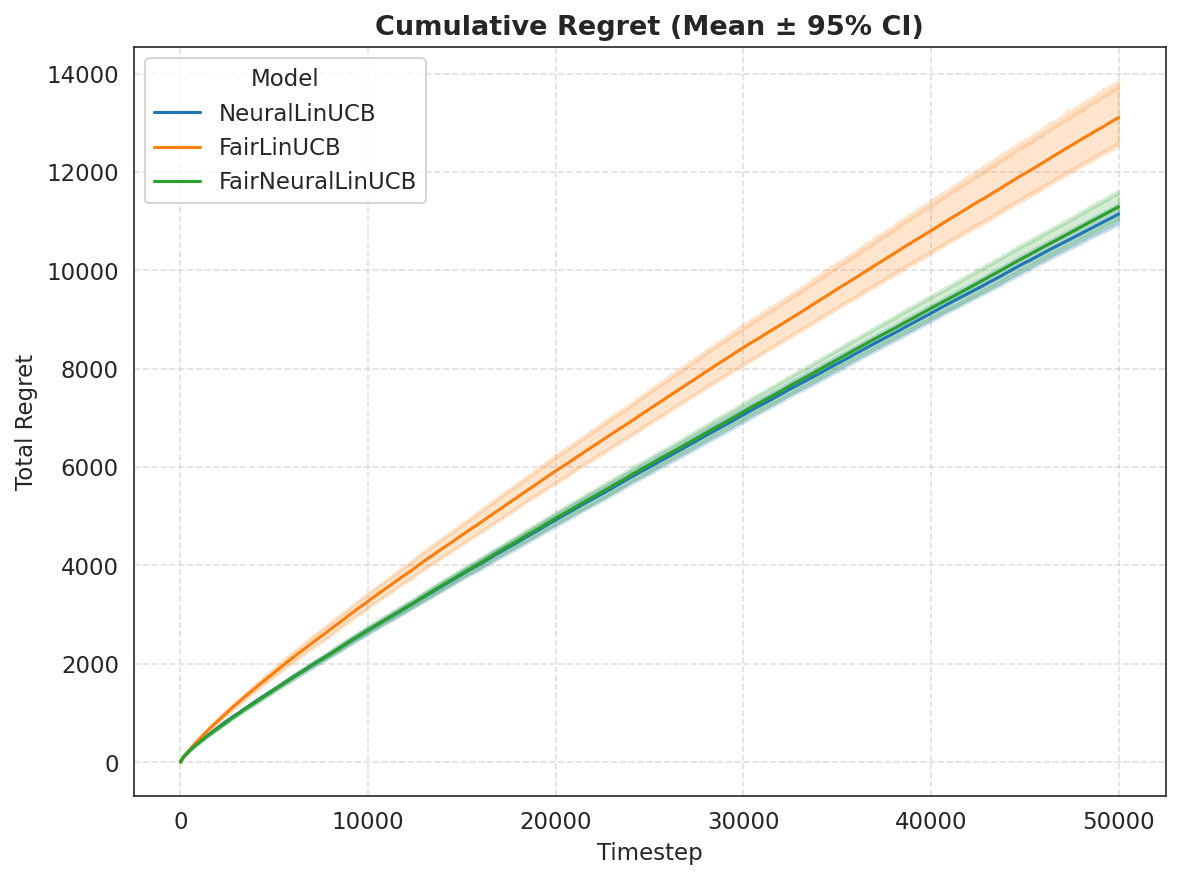

In [137]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=combined_df, x='timestep', y='cum_regret', hue='model')
plt.title("Cumulative Regret (Mean ± 95% CI)", fontsize=13, fontweight='bold')
plt.ylabel("Total Regret")
plt.xlabel("Timestep")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Model", loc='upper left')
plt.tight_layout()
plt.savefig("regret_plot.png", dpi=300)
plt.show()

Instantaneous Reward Curve

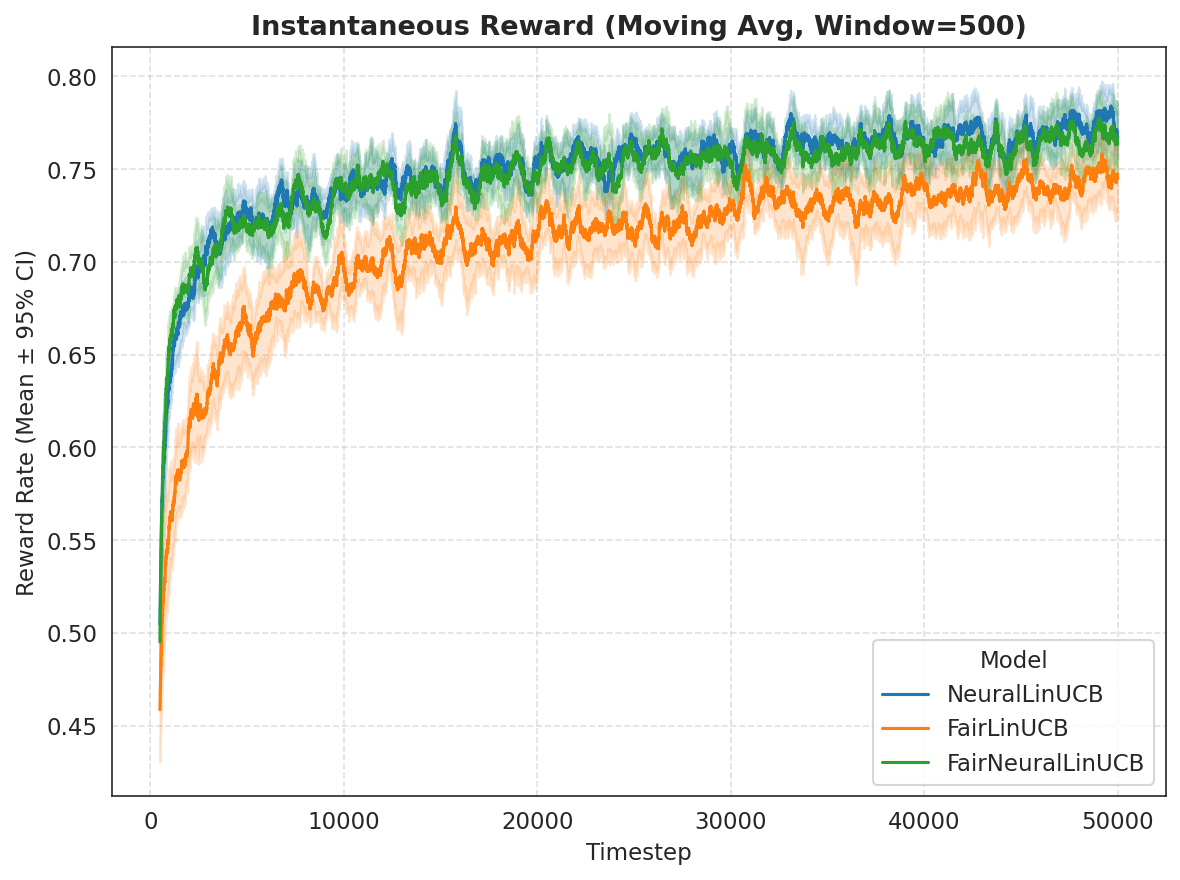

In [138]:
plt.figure(figsize=(8, 6))
# Using the smoothed_reward calculated in your earlier step
sns.lineplot(data=combined_df, x='timestep', y='smoothed_reward', hue='model')
plt.title(f"Instantaneous Reward (Moving Avg, Window={WINDOW})", fontsize=13, fontweight='bold')
plt.ylabel("Reward Rate (Mean ± 95% CI)")
plt.xlabel("Timestep")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Model", loc='lower right')
plt.tight_layout()
plt.savefig("reward_plot.png", dpi=300)
plt.show()

Gender based hit rate

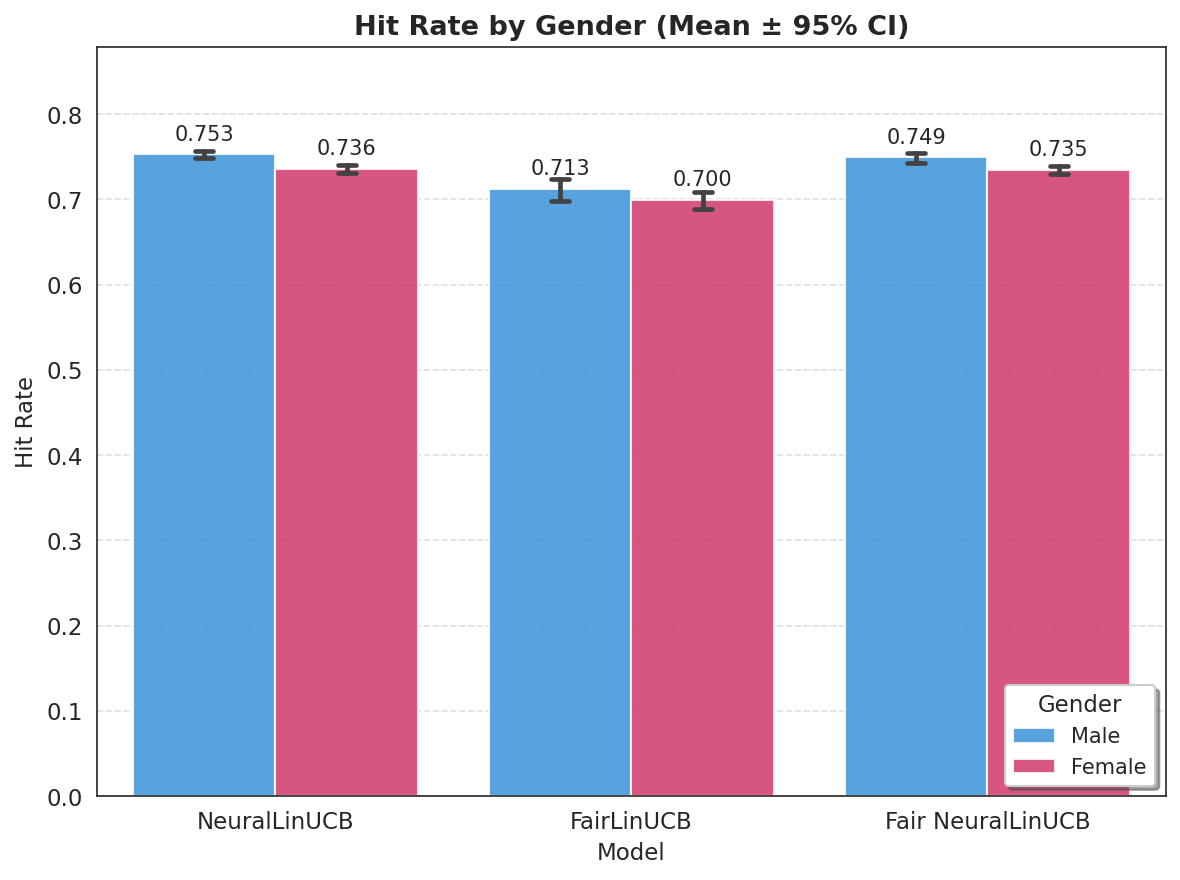

In [139]:
# Create a long-form dataframe for gendered hit rates
plot_data_list = []
for model_name, stats_df in perf_summary.items():
    # Process Male Hit Rates
    for val in stats_df['hit_m']:
        plot_data_list.append({'Model': model_name, 'Gender': 'Male', 'Hit Rate': val})
    # Process Female Hit Rates
    for val in stats_df['hit_f']:
        plot_data_list.append({'Model': model_name, 'Gender': 'Female', 'Hit Rate': val})

gender_df = pd.DataFrame(plot_data_list)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=gender_df, 
    x='Model', 
    y='Hit Rate', 
    hue='Gender', 
    palette={'Male': '#2196F3', 'Female': '#E91E63'},
    capsize=.1,
    errorbar=('ci', 95),
    alpha=0.85
)

# Adding value labels on top of bars
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                    textcoords='offset points')

plt.title("Hit Rate by Gender (Mean ± 95% CI)", fontsize=13, fontweight='bold')
plt.ylabel("Hit Rate")
plt.xlabel("Model")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Gender', loc='lower right', frameon=True, shadow=True, fontsize=10)
plt.ylim(0, gender_df['Hit Rate'].max() * 1.15)
plt.tight_layout()
plt.savefig("gender_hitrate_plot.png", dpi=300)
plt.show()

In [143]:
from scipy import stats

class SignificanceTester:
    def __init__(self, results_dir, alpha=0.05):
        self.results_dir = results_dir
        self.alpha = alpha
        self.all_sig_results = []

    def _get_seed_totals(self, file_name):
        path = os.path.join(self.results_dir, file_name)
        if not os.path.exists(path):
            print(f"Error: File {file_name} not found.")
            return None
        
        df = pd.read_csv(path)
        results = []

        # Group by seed to get independent observations for the tests
        for seed in df['random_seed'].unique():
            subset = df[df['random_seed'] == seed]
            
            # Metric Calculation
            m_rate = subset[subset['gender'] == 'M']['reward'].mean()
            f_rate = subset[subset['gender'] == 'F']['reward'].mean()
            gender_gap = abs(m_rate - f_rate)
            
            results.append({
                'random_seed': seed,
                'reward': subset['reward'].sum(),
                'regret': subset['regret'].sum(),
                'gender_gap': gender_gap
            })
            
        return pd.DataFrame(results).set_index('random_seed')

    def run_test(self, values_a, values_b, label_a, label_b, metric, n_comparisons):
        n = min(len(values_a), len(values_b))
        a, b = np.array(values_a[:n]), np.array(values_b[:n])
        diff = a - b

        # 1. Bonferroni Correction
        alpha_corrected = self.alpha / n_comparisons

        # 2. Normality Check (Shapiro-Wilk)
        # If diff is normal, use T-test; otherwise, use Wilcoxon
        stat_sw, p_sw = stats.shapiro(diff) if n >= 3 else (np.nan, 0.0)
        is_normal = p_sw > 0.05

        # 3. Significance Tests
        _, p_ttest = stats.ttest_rel(a, b)
        try:
            _, p_wilcox = stats.wilcoxon(diff)
        except ValueError:
            p_wilcox = 1.0

        # 4. Effect Size (Cohen's d)
        std_diff = np.std(diff, ddof=1)
        cohens_d = np.mean(diff) / std_diff if std_diff > 0 else 0.0

        preferred_p = p_ttest if is_normal else p_wilcox
        preferred_test = 'Paired T-test' if is_normal else 'Wilcoxon'
        
        return {
            'Metric': metric,
            'Model_A': label_a, 'Model_B': label_b,
            'N_seeds': n,
            'Mean_A': np.mean(a), 'Mean_B': np.mean(b),
            'Mean_diff': np.mean(diff), 'Cohens_d': cohens_d,
            'Normally_dist': is_normal,
            'Preferred_test': preferred_test,
            'Preferred_p': preferred_p,
            'Alpha_corrected': alpha_corrected,
            'Significant': preferred_p < alpha_corrected
        }

    def compare(self, files_dict, key_a, key_b):
        """Pass the dictionary and the keys you want to compare."""
        data_a = self._get_seed_totals(files_dict[key_a])
        data_b = self._get_seed_totals(files_dict[key_b])

        if data_a is None or data_b is None: return

        metrics = ['reward', 'regret', 'gender_gap']
        
        for metric in metrics:
            res = self.run_test(
                data_a[metric].tolist(), 
                data_b[metric].tolist(),
                key_a, key_b, metric, 
                n_comparisons=len(metrics)
            )
            self.all_sig_results.append(res)

    def print_results(self):
        df = pd.DataFrame(self.all_sig_results)
        print(f"\n{'Metric':<12} {'Comparison':<30} {'Test':<15} {'p-val':<10} {'d':<8} {'Sig?'}")
        print("-" * 90)
        for _, r in df.iterrows():
            comp = f"{r['Model_A']} vs {r['Model_B']}"
            sig = "✓ YES" if r['Significant'] else "✗ no"
            print(f"{r['Metric']:<12} {comp:<30} {r['Preferred_test']:<15} "
                  f"{r['Preferred_p']:<10.4f} {r['Cohens_d']:<8.3f} {sig}")


In [144]:
RESULTS_DIR = 'results'
FILES = {
    'NeuralLinUCB': 'combined_log_neurallinucb.csv',
    'FairLinUCB': 'combined_log_Fairlinucb.csv'
}

tester = SignificanceTester(results_dir=RESULTS_DIR, alpha=0.05)

tester.compare(FILES, 'NeuralLinUCB', 'FairLinUCB')
tester.print_results()


Metric       Comparison                     Test            p-val      d        Sig?
------------------------------------------------------------------------------------------
reward       NeuralLinUCB vs FairLinUCB     Paired T-test   0.0001     2.031    ✓ YES
regret       NeuralLinUCB vs FairLinUCB     Paired T-test   0.0001     -2.031   ✓ YES
gender_gap   NeuralLinUCB vs FairLinUCB     Paired T-test   0.3398     0.319    ✗ no


In [145]:
RESULTS_DIR = 'results'
FILES = {
    'NeuralLinUCB': 'combined_log_neurallinucb.csv',
    'FairNeuralLinUCB': 'combined_log_fair_neurallinucb.csv'
}

tester = SignificanceTester(results_dir=RESULTS_DIR, alpha=0.05)

tester.compare(FILES, 'NeuralLinUCB', 'FairNeuralLinUCB')
tester.print_results()


Metric       Comparison                     Test            p-val      d        Sig?
------------------------------------------------------------------------------------------
reward       NeuralLinUCB vs FairNeuralLinUCB Paired T-test   0.3753     0.295    ✗ no
regret       NeuralLinUCB vs FairNeuralLinUCB Paired T-test   0.3753     -0.295   ✗ no
gender_gap   NeuralLinUCB vs FairNeuralLinUCB Paired T-test   0.3056     0.343    ✗ no


In [146]:
RESULTS_DIR = 'results'
FILES = {
    'FairLinUCB': 'combined_log_Fairlinucb.csv',
    'FairNeuralLinUCB': 'combined_log_fair_neurallinucb.csv'
}

tester = SignificanceTester(results_dir=RESULTS_DIR, alpha=0.05)

tester.compare(FILES, 'FairLinUCB', 'FairNeuralLinUCB')
tester.print_results()


Metric       Comparison                     Test            p-val      d        Sig?
------------------------------------------------------------------------------------------
reward       FairLinUCB vs FairNeuralLinUCB Paired T-test   0.0011     -1.488   ✓ YES
regret       FairLinUCB vs FairNeuralLinUCB Paired T-test   0.0011     1.488    ✓ YES
gender_gap   FairLinUCB vs FairNeuralLinUCB Paired T-test   0.6231     -0.161   ✗ no
